# Phase 1: Model Base Swap & Hyperparameter Optimization

## BEA 2026 Shared Task — Vocabulary Difficulty Prediction

---

### Objective / Objetivo

**EN:** This notebook implements Phase 1 of our improvement strategy over the official BEA 2026 baselines. The baselines use `xlm-roberta-base` with generic hyperparameters. Our goal is to achieve measurable gains in RMSE and Pearson correlation by:

1. **Swapping the base model** — testing stronger pretrained transformers (both multilingual and L1-specific).
2. **Optimizing hyperparameters** — systematically tuning learning rate, epochs, weight decay, and warmup.
3. **Comparing all results** against the official baselines on the dev set.

**ES:** Este notebook implementa la Fase 1 de nuestra estrategia de mejora sobre los baselines oficiales de BEA 2026. Los baselines utilizan `xlm-roberta-base` con hiperparámetros genéricos. Nuestro objetivo es lograr mejoras medibles en RMSE y correlación de Pearson mediante:

1. **Cambio del modelo base** — probar transformers preentrenados más potentes (multilingües y específicos por L1).
2. **Optimización de hiperparámetros** — ajustar sistemáticamente learning rate, épocas, weight decay y warmup.
3. **Comparar todos los resultados** contra los baselines oficiales en el conjunto dev.

---

### Baseline Performance (reference / referencia)

| Track | Model | L1 | RMSE | Pearson |
|-------|-------|----|------|---------|
| closed | baseline_closed_es | es | 1.357 | 0.748 |
| closed | baseline_closed_de | de | 1.328 | 0.753 |
| closed | baseline_closed_cn | cn | 1.175 | 0.736 |
| open | baseline_open_xx | es | 1.206 | 0.787 |
| open | baseline_open_xx | de | 1.149 | 0.800 |
| open | baseline_open_xx | cn | 1.021 | 0.804 |

All baselines use `xlm-roberta-base`, LR=3e-5, 5 epochs, batch_size=32.

---

### Experiment Design / Diseño experimental

| Experiment ID | Track | Model | L1 | Key Changes |
|--------------|-------|-------|----|-------------|
| `exp1_open_xlmr_large` | open | `xlm-roberta-large` | xx | Larger model, lower LR |
| `exp2_open_mdeberta` | open | `microsoft/mdeberta-v3-base` | xx | State-of-the-art multilingual |
| `exp3_closed_es_beto` | closed | `dccuchile/bert-base-spanish-wwm-cased` | es | Spanish-specific model |
| `exp4_closed_de_gbert` | closed | `deepset/gbert-base` | de | German-specific model |
| `exp5_closed_cn_chinese` | closed | `hfl/chinese-roberta-wwm-ext` | cn | Chinese-specific model |
| `exp6_open_xlmr_tuned` | open | `xlm-roberta-base` | xx | Same model, optimized hyperparams |

---

### Important Note / Nota importante

**EN:** We discovered that the baselines already use `xlm-roberta-base` (not `bert-base-multilingual-cased` as initially assumed). This means our strategies focus on (a) scaling up to `xlm-roberta-large`, (b) trying newer architectures like mDeBERTa, (c) L1-specific models for the closed track, and (d) hyperparameter tuning.

**ES:** Descubrimos que los baselines ya usan `xlm-roberta-base` (no `bert-base-multilingual-cased` como se asumió inicialmente). Esto significa que nuestras estrategias se enfocan en (a) escalar a `xlm-roberta-large`, (b) probar arquitecturas más nuevas como mDeBERTa, (c) modelos específicos por L1 para el closed track, y (d) optimización de hiperparámetros.

## About the Target Variable: `GLMM_score`

The target variable `GLMM_score` represents the **difficulty estimate** for each vocabulary test item, derived from a **Generalised Linear Mixed Model (GLMM)** fitted to binary correct/incorrect response data from English learners.

> *"Item difficulty was estimated using a Generalised Linear Mixed Model (GLMM) with a logit link function fitted to binary response data (correct/incorrect). The model included random intercepts for participants and fixed effects for items, yielding item-level difficulty estimates on the log-odds scale. A lower GLMM score indicates a more difficult item."*
>
> — Schmitt, N., Dörnyei, Z., Adolphs, S., & Durow, V. (2024). *Knowledge-based Vocabulary Lists.* British Council Research and Insight. [https://www.britishcouncil.org/research-insight/knowledge-based-vocabulary-lists](https://www.britishcouncil.org/research-insight/knowledge-based-vocabulary-lists)

**Key properties:**
- **Scale:** Log-odds (approximately **-7 to +5** in our data)
- **Interpretation:** Lower score → harder word; Higher score → easier word
- **Random effects:** Participant variability is accounted for, so the scores reflect intrinsic item difficulty rather than learner ability

See also: Skidmore, L., et al. (2025). *Predicting Vocabulary Difficulty for English Learners.* Proceedings of the 20th Workshop on Innovative Use of NLP for Building Educational Applications (BEA), ACL 2025. [https://doi.org/10.18653/v1/2025.bea-1.12](https://doi.org/10.18653/v1/2025.bea-1.12)

## 0. Setup

In [1]:
import os
import sys
import logging
import gc
import csv
import warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import torch
from sklearn.metrics import root_mean_squared_error
from scipy.stats import pearsonr
from datasets import load_dataset

from transformers import (
    AutoTokenizer,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    AutoModelForSequenceClassification,
    set_seed,
)

warnings.filterwarnings("ignore")

# Add bea2026st to path to reuse utilities
BEA_DIR = Path("bea2026st")
sys.path.insert(0, str(BEA_DIR))
from utils import (
    compute_metrics,
    merge_cols,
    preprocess_dataset,
    save_predictions,
    cleanup_trainer_memory,
    load_data_paths,
)

# Paths
DATA_DIR = BEA_DIR / "data"
MODELS_DIR = BEA_DIR / "models"
PRED_DIR = BEA_DIR / "predictions"
RESULTS_DIR = BEA_DIR / "results"

SEED = 42
set_seed(SEED)

# Device info
device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Device: {device}")
print(f"PyTorch: {torch.__version__}")
if device == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_mem / 1e9:.1f} GB")

c:\Users\adria\miniconda3\envs\baseline_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cpu
PyTorch: 2.10.0+cpu


## 1. Define Experiments

We define all experiments as a DataFrame for easy iteration and tracking.

Each row specifies: model name, track, pretrained checkpoint, target L1, input column order, and hyperparameters.

In [2]:
# --- Experiment configurations ---
COMPONENT_ORDER = "L1_source_word; L1_context; en_target_clue; en_target_word"

experiments = pd.DataFrame([
    # Experiment 1: XLM-RoBERTa Large (Open track)
    {
        "model_name": "exp1_open_xlmr_large",
        "track": "open",
        "pretrained_model": "xlm-roberta-large",
        "L1": "xx",
        "component_order": COMPONENT_ORDER,
        "batch_size": 16,          # Smaller batch for large model
        "learning_rate": 1e-5,     # Lower LR for large models
        "weight_decay": 0.1,
        "warmup_ratio": 0.1,
        "epochs": 5,
    },
    # Experiment 2: mDeBERTa-v3 (Open track)
    {
        "model_name": "exp2_open_mdeberta",
        "track": "open",
        "pretrained_model": "microsoft/mdeberta-v3-base",
        "L1": "xx",
        "component_order": COMPONENT_ORDER,
        "batch_size": 32,
        "learning_rate": 2e-5,
        "weight_decay": 0.1,
        "warmup_ratio": 0.1,
        "epochs": 8,
    },
    # Experiment 3: BETO — Spanish BERT (Closed track, ES)
    {
        "model_name": "exp3_closed_es_beto",
        "track": "closed",
        "pretrained_model": "dccuchile/bert-base-spanish-wwm-cased",
        "L1": "es",
        "component_order": COMPONENT_ORDER,
        "batch_size": 32,
        "learning_rate": 2e-5,
        "weight_decay": 0.1,
        "warmup_ratio": 0.1,
        "epochs": 8,
    },
    # Experiment 4: GBERT — German BERT (Closed track, DE)
    {
        "model_name": "exp4_closed_de_gbert",
        "track": "closed",
        "pretrained_model": "deepset/gbert-base",
        "L1": "de",
        "component_order": COMPONENT_ORDER,
        "batch_size": 32,
        "learning_rate": 2e-5,
        "weight_decay": 0.1,
        "warmup_ratio": 0.1,
        "epochs": 8,
    },
    # Experiment 5: Chinese RoBERTa (Closed track, CN)
    {
        "model_name": "exp5_closed_cn_chinese",
        "track": "closed",
        "pretrained_model": "hfl/chinese-roberta-wwm-ext",
        "L1": "cn",
        "component_order": COMPONENT_ORDER,
        "batch_size": 32,
        "learning_rate": 2e-5,
        "weight_decay": 0.1,
        "warmup_ratio": 0.1,
        "epochs": 8,
    },
    # Experiment 6: XLM-RoBERTa Base with tuned hyperparams (Open track)
    {
        "model_name": "exp6_open_xlmr_tuned",
        "track": "open",
        "pretrained_model": "xlm-roberta-base",
        "L1": "xx",
        "component_order": COMPONENT_ORDER,
        "batch_size": 16,
        "learning_rate": 2e-5,     # Slightly lower than baseline 3e-5
        "weight_decay": 0.01,      # Less regularization 
        "warmup_ratio": 0.06,
        "epochs": 10,              # More epochs
    },
])

print(f"Total experiments: {len(experiments)}")
experiments[["model_name", "track", "pretrained_model", "L1", "learning_rate", "epochs"]]

Total experiments: 6


,model_name,track,pretrained_model,L1,learning_rate,epochs
0,exp1_open_xlmr_large,open,xlm-roberta-large,xx,0.00001,5
1,exp2_open_mdeberta,open,microsoft/mdeberta-v3-base,xx,0.00002,8
2,exp3_closed_es_beto,closed,dccuchile/bert-base-spanish-wwm-cased,es,0.00002,8
3,exp4_closed_de_gbert,closed,deepset/gbert-base,de,0.00002,8
4,exp5_closed_cn_chinese,closed,hfl/chinese-roberta-wwm-ext,cn,0.00002,8
5,exp6_open_xlmr_tuned,open,xlm-roberta-base,xx,0.00002,10


## 2. Fine-Tuning Loop

This section fine-tunes each experiment sequentially, reusing the pipeline utilities from the original codebase.

For each experiment:
1. Load and preprocess the appropriate data (single L1 for closed, all L1s for open).
2. Tokenize with the corresponding tokenizer.
3. Train with the specified hyperparameters.
4. Save the best checkpoint.

**Note:** Run only the experiments you need. You can filter by index or model_name.

In [3]:
def finetune_experiment(row, seed=SEED):
    """
    Fine-tune a single experiment defined by a row from the experiments DataFrame.
    Reuses the same logic as the official pipeline but with custom parameters.
    """
    model_name = row["model_name"]
    l1 = row["L1"]
    pretrained = row["pretrained_model"]
    
    print(f"\n{'='*70}")
    print(f"  Fine-tuning: {model_name}")
    print(f"  Model: {pretrained} | Track: {row['track']} | L1: {l1}")
    print(f"  LR: {row['learning_rate']} | Epochs: {row['epochs']} | Batch: {row['batch_size']}")
    print(f"{'='*70}\n")
    
    # Load data
    data_files = load_data_paths(DATA_DIR, l1, "finetune")
    hf_dataset = load_dataset("csv", data_files=data_files)
    
    # Tokenizer
    tokenizer = AutoTokenizer.from_pretrained(pretrained, use_fast=True)
    cols_to_merge = row["component_order"].split("; ")
    sep_token = f" {tokenizer.sep_token} " if tokenizer.sep_token else " "
    
    # Preprocess
    preprocessed_ds = preprocess_dataset(hf_dataset, cols_to_merge, sep_token)
    
    # Tokenize
    tokenized_ds = preprocessed_ds.map(
        lambda x: tokenizer(x["input_text"], truncation=True, max_length=256),
        batched=True,
        desc="Tokenizing"
    )
    
    # Output directory
    output_dir = MODELS_DIR / model_name
    
    # Training arguments
    training_args = TrainingArguments(
        output_dir=str(output_dir),
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="epoch",
        save_total_limit=1,
        num_train_epochs=int(row["epochs"]),
        per_device_train_batch_size=int(row["batch_size"]),
        per_device_eval_batch_size=int(row["batch_size"]),
        learning_rate=float(row["learning_rate"]),
        weight_decay=float(row["weight_decay"]),
        warmup_ratio=float(row["warmup_ratio"]),
        load_best_model_at_end=True,
        metric_for_best_model="rmse",
        greater_is_better=False,
        report_to="none",
        seed=seed,
        fp16=torch.cuda.is_available(),  # Mixed precision if GPU available
    )
    
    # Trainer
    data_collator = DataCollatorWithPadding(tokenizer)
    trainer = Trainer(
        model_init=lambda: AutoModelForSequenceClassification.from_pretrained(
            pretrained, num_labels=1
        ),
        args=training_args,
        train_dataset=tokenized_ds["train"],
        eval_dataset=tokenized_ds["validation"],
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )
    
    # Train
    train_result = trainer.train()
    
    # Save best model
    trainer.save_model(output_dir)
    tokenizer.save_pretrained(output_dir)
    
    # Final evaluation on dev
    eval_metrics = trainer.evaluate()
    print(f"\n✓ {model_name} complete — Dev RMSE: {eval_metrics['eval_rmse']:.4f} | Pearson: {eval_metrics['eval_pearson']:.4f}")
    
    # Cleanup
    cleanup_trainer_memory(trainer, tokenized_ds, preprocessed_ds)
    
    return {
        "model_name": model_name,
        "track": row["track"],
        "pretrained_model": pretrained,
        "L1": l1,
        "dev_rmse": eval_metrics["eval_rmse"],
        "dev_pearson": eval_metrics["eval_pearson"],
        "train_loss": train_result.training_loss,
    }

print("Fine-tuning function defined.")

Fine-tuning function defined.


In [ ]:
# ============================================================
# Run ALL experiments (or select specific ones by index/name)
# ============================================================
# To run specific experiments, filter the DataFrame:
#   to_run = experiments[experiments["model_name"].isin(["exp1_open_xlmr_large"])]
#   to_run = experiments.iloc[0:1]  # Run only experiment 1

to_run = experiments  # Run all

training_results = []

for idx, row in to_run.iterrows():
    try:
        result = finetune_experiment(row)
        training_results.append(result)
    except Exception as e:
        print(f"\n✗ FAILED: {row['model_name']} — {e}")
        training_results.append({
            "model_name": row["model_name"],
            "track": row["track"],
            "pretrained_model": row["pretrained_model"],
            "L1": row["L1"],
            "dev_rmse": None,
            "dev_pearson": None,
            "train_loss": None,
        })

# Summarize
results_df = pd.DataFrame(training_results)
print("\n" + "="*70)
print("  TRAINING SUMMARY")
print("="*70)
print(results_df.to_string(index=False))


  Fine-tuning: exp1_open_xlmr_large
  Model: xlm-roberta-large | Track: open | L1: xx
  LR: 1e-05 | Epochs: 5 | Batch: 16



Generating train split: 18273 examples [00:00, 105646.64 examples/s]
Generating validation split: 2031 examples [00:00, 68543.31 examples/s]
Tokenizing: 100%|██████████| 2031/2031 [00:00<00:00, 9774.68 examples/s] 
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
Loading weights: 100%|██████████| 389/389 [00:01<00:00, 258.07it/s, Materializing param=roberta.encoder.layer.23.output.dense.weight]              
XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-large
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    

Epoch,Training Loss,Validation Loss


## 3. Predict on Dev Set

Generate predictions for each trained model on each applicable L1 dev set.

- **Closed track models:** Predict only on their L1.
- **Open track models:** Predict on all 3 L1s (es, de, cn).

In [ ]:
def predict_experiment(row, dataset_split="dev"):
    """
    Generate predictions for a fine-tuned experiment model on the dev set.
    """
    model_name = row["model_name"]
    track = row["track"]
    l1 = row["L1"]
    pretrained = row["pretrained_model"]
    
    l1_datasets = ["es", "de", "cn"] if l1 == "xx" else [l1]
    model_path = MODELS_DIR / model_name
    
    if not model_path.exists():
        print(f"  ✗ Model not found: {model_path}. Skipping.")
        return
    
    for target_l1 in l1_datasets:
        print(f"  Predicting: {model_name} on L1={target_l1} ({dataset_split})")
        
        # Load data
        data_files = load_data_paths(DATA_DIR, target_l1, "predict", dataset_split=dataset_split)
        if not data_files:
            print(f"    No data found for {target_l1} {dataset_split}. Skipping.")
            continue
        
        hf_dataset = load_dataset("csv", data_files=data_files)
        
        # Tokenizer from saved model
        tokenizer = AutoTokenizer.from_pretrained(model_path, use_fast=True)
        cols_to_merge = row["component_order"].split("; ")
        sep_token = f" {tokenizer.sep_token} " if tokenizer.sep_token else " "
        
        # Preprocess & tokenize
        preprocessed_ds = preprocess_dataset(hf_dataset, cols_to_merge, sep_token)
        tokenized_ds = preprocessed_ds.map(
            lambda x: tokenizer(x["input_text"], truncation=True, max_length=256),
            batched=True, desc="Tokenizing"
        )
        
        # Load model
        model = AutoModelForSequenceClassification.from_pretrained(model_path)
        model.eval()
        
        # Trainer for inference
        data_collator = DataCollatorWithPadding(tokenizer)
        trainer = Trainer(
            model=model,
            data_collator=data_collator,
            args=TrainingArguments(output_dir=str(model_path), report_to="none"),
        )
        
        # Predict
        hf_key = "validation" if dataset_split == "dev" else "test"
        with torch.no_grad():
            preds = trainer.predict(tokenized_ds[hf_key]).predictions.flatten()
        
        # Save predictions
        item_ids = hf_dataset[hf_key]["item_id"]
        save_dir = PRED_DIR / track / dataset_split / target_l1
        save_dir.mkdir(parents=True, exist_ok=True)
        save_path = save_dir / f"{model_name}_preds.csv"
        save_predictions(save_path, item_ids, preds)
        print(f"    ✓ Saved: {save_path}")
        
        # Cleanup
        cleanup_trainer_memory(trainer, tokenized_ds, preprocessed_ds)


# Run predictions for all trained models
print("Generating dev predictions...\n")
for idx, row in experiments.iterrows():
    predict_experiment(row)

print("\n✓ All predictions complete.")

## 4. Evaluate & Compare with Baselines

Compute RMSE and Pearson for each experiment and compare side-by-side with the official baselines.

In [ ]:
def evaluate_all_predictions(dataset_split="dev"):
    """
    Evaluate all prediction CSV files found in PRED_DIR and return a results DataFrame.
    """
    eval_results = []
    
    for pred_path in PRED_DIR.rglob("*.csv"):
        try:
            rel = pred_path.relative_to(PRED_DIR)
            track, split, l1, filename = rel.parts
            
            if split != dataset_split:
                continue
            
            stem = pred_path.stem
            if not stem.endswith("_preds"):
                continue
            
            model_name = stem.replace("_preds", "")
            
            # Load labels and predictions
            labels_df = pd.read_csv(DATA_DIR / split / l1 / f"kvl_shared_task_{l1}_{split}.csv")
            preds_df = pd.read_csv(pred_path)
            
            merged = labels_df.merge(preds_df[["item_id", "prediction"]], on="item_id", how="left")
            
            labels = merged["GLMM_score"].values
            predictions = merged["prediction"].values
            
            eval_results.append({
                "model": model_name,
                "track": track,
                "L1": l1,
                "rmse": root_mean_squared_error(labels, predictions),
                "pearson": pearsonr(predictions, labels)[0],
            })
        except Exception as e:
            print(f"  Skipped {pred_path}: {e}")
    
    df = pd.DataFrame(eval_results)
    L1_order = ["es", "de", "cn"]
    df["L1"] = pd.Categorical(df["L1"], categories=L1_order, ordered=True)
    df = df.sort_values(["track", "model", "L1"])
    return df

# Run evaluation
all_results = evaluate_all_predictions("dev")
print(f"Total evaluations: {len(all_results)}")
all_results.round(4)

In [ ]:
import matplotlib.pyplot as plt

# --- CLOSED TRACK comparison ---
closed_results = all_results[all_results["track"] == "closed"].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("CLOSED TRACK — Baseline vs Phase 1 Experiments", fontsize=14, fontweight="bold")

for ax, metric, better in zip(axes, ["rmse", "pearson"], ["lower", "higher"]):
    pivot = closed_results.pivot(index="L1", columns="model", values=metric)
    pivot.plot(kind="bar", ax=ax, rot=0)
    ax.set_title(f"{metric.upper()} ({better} is better)")
    ax.set_ylabel(metric.upper())
    ax.legend(fontsize=8, loc="best")
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# --- OPEN TRACK comparison ---
open_results = all_results[(all_results["track"] == "open")].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("OPEN TRACK — Baseline vs Phase 1 Experiments", fontsize=14, fontweight="bold")

for ax, metric, better in zip(axes, ["rmse", "pearson"], ["lower", "higher"]):
    pivot = open_results.pivot(index="L1", columns="model", values=metric)
    pivot.plot(kind="bar", ax=ax, rot=0)
    ax.set_title(f"{metric.upper()} ({better} is better)")
    ax.set_ylabel(metric.upper())
    ax.legend(fontsize=8, loc="best")
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# --- Improvement table: Delta vs baselines ---

# Define baseline references
baseline_ref = {
    ("closed", "es"): {"rmse": 1.357, "pearson": 0.748, "model": "baseline_closed_es"},
    ("closed", "de"): {"rmse": 1.328, "pearson": 0.753, "model": "baseline_closed_de"},
    ("closed", "cn"): {"rmse": 1.175, "pearson": 0.736, "model": "baseline_closed_cn"},
    ("open", "es"): {"rmse": 1.206, "pearson": 0.787, "model": "baseline_open_xx"},
    ("open", "de"): {"rmse": 1.149, "pearson": 0.800, "model": "baseline_open_xx"},
    ("open", "cn"): {"rmse": 1.021, "pearson": 0.804, "model": "baseline_open_xx"},
}

# Only compare non-baseline models
exp_results = all_results[~all_results["model"].str.startswith("baseline")].copy()

deltas = []
for _, row in exp_results.iterrows():
    key = (row["track"], row["L1"])
    if key in baseline_ref:
        ref = baseline_ref[key]
        delta_rmse = ref["rmse"] - row["rmse"]        # Positive = improvement
        delta_pearson = row["pearson"] - ref["pearson"]  # Positive = improvement
        deltas.append({
            "model": row["model"],
            "track": row["track"],
            "L1": row["L1"],
            "rmse": row["rmse"],
            "pearson": row["pearson"],
            "baseline_rmse": ref["rmse"],
            "baseline_pearson": ref["pearson"],
            "Δ_rmse": delta_rmse,
            "Δ_pearson": delta_pearson,
            "improved_rmse": "✓" if delta_rmse > 0 else "✗",
            "improved_pearson": "✓" if delta_pearson > 0 else "✗",
        })

delta_df = pd.DataFrame(deltas)
print("\n" + "="*80)
print("  IMPROVEMENT vs BASELINE (positive Δ = better than baseline)")
print("="*80)
print(delta_df[["model", "track", "L1", "rmse", "Δ_rmse", "improved_rmse", 
                "pearson", "Δ_pearson", "improved_pearson"]].round(4).to_string(index=False))

In [ ]:
# Save updated results summary
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
all_results.to_csv(RESULTS_DIR / "results_summary_phase1_dev.csv", index=False)

if len(deltas) > 0:
    delta_df.to_csv(RESULTS_DIR / "results_delta_vs_baseline.csv", index=False)

print(f"✓ Results saved to {RESULTS_DIR}")

## 5. Phase 1 Conclusions / Conclusiones Fase 1

### 🇪🇸 Conclusiones

*(Completar tras ejecutar los experimentos)*

- **Mejor modelo open track:**  `[modelo]` — RMSE: `[valor]`, Pearson: `[valor]`
- **Mejor modelo closed ES:** `[modelo]` — RMSE: `[valor]`, Pearson: `[valor]`
- **Mejor modelo closed DE:** `[modelo]` — RMSE: `[valor]`, Pearson: `[valor]`
- **Mejor modelo closed CN:** `[modelo]` — RMSE: `[valor]`, Pearson: `[valor]`
- **Mejora máxima en RMSE:** `[valor]` puntos (modelo: `[nombre]`)
- **Hallazgo principal:** *(ej: XLM-R Large supera al base en X puntos)*

### 🇬🇧 Conclusions

*(To be filled after running experiments)*

- **Best open track model:** `[model]` — RMSE: `[value]`, Pearson: `[value]`
- **Best closed ES model:** `[model]` — RMSE: `[value]`, Pearson: `[value]`
- **Best closed DE model:** `[model]` — RMSE: `[value]`, Pearson: `[value]`
- **Best closed CN model:** `[model]` — RMSE: `[value]`, Pearson: `[value]`
- **Maximum RMSE improvement:** `[value]` points (model: `[name]`)
- **Key finding:** *(e.g., XLM-R Large outperforms base by X points)*

---

## 6. Phase 2 Plan: Linguistic Feature Engineering

### Motivation / Motivación

**EN:** Phase 1 focuses on swapping transformer backbones and tuning hyperparameters. However, vocabulary difficulty prediction is inherently a **psycholinguistic problem** — the difficulty of a word for an L2 learner depends on complex interactions between the target word's properties and the learner's L1. Phase 2 aims to capture these interactions through **linguistically-motivated features** that go beyond what a transformer can learn from raw text alone.

**ES:** La Fase 1 se centra en cambiar el backbone del transformer y ajustar hiperparámetros. Sin embargo, la predicción de dificultad de vocabulario es intrínsecamente un **problema psicolingüístico** — la dificultad de una palabra para un aprendiz de L2 depende de interacciones complejas entre las propiedades de la palabra objetivo y la L1 del aprendiz. La Fase 2 busca capturar estas interacciones mediante **features lingüísticamente motivadas**.

### Feature Summary Table

| # | Feature | Type | Source | Rationale |
|---|---------|------|--------|-----------|
| 1 | **Word length** | numeric | `en_target_word` | Longer words are harder to spell and recall (EDA: r ≈ -0.38) |
| 2 | **Clue ratio** | numeric | `en_target_clue` | Proportion of hidden letters in the partial-spelling clue |
| 3 | **Polysemy count** | numeric | WordNet | Number of synsets — polysemous words may be easier (more contexts) or harder (ambiguity) |
| 4 | **Homonymy flag** | binary | WordNet | Whether the word has unrelated meanings across POS — may confuse learners |
| 5 | **Cosine distance (L1↔EN)** | numeric | Multilingual embeddings | Semantic distance between `L1_source_word` and `en_target_word` — L1-specific |
| 6 | **Letters absent from L1 alphabet** | numeric | Alphabet sets | Count of characters in `en_target_word` absent from the L1 writing system |
| 7 | **Consonant cluster count** | numeric | Regex | Number of clusters of ≥2 consecutive consonants — hard for Mandarin L1 |
| 8 | **Max consonant cluster length** | numeric | Regex | Length of the longest consonant cluster |
| 9 | **Rhotacism indicator** | binary + L1-weighted | Phonological rules | Presence of /r/ phoneme — problematic for Mandarin and some L1 backgrounds |
| 10 | **Aphthong / Silent letters** | numeric | CMU Pronouncing Dict | Letters in spelling not realized as phonemes ("knight" → 2 silent letters) |
| 11 | **Syntactic overlap (L1↔EN)** | categorical | Typological knowledge | Whether POS and word-order conventions align between L1 and English |
| 12 | **Phoneme count** | numeric | CMU Pronouncing Dict | Total phonemes — pronunciation complexity independent of spelling |
| 13 | **Spelling–phoneme ratio** | numeric | Derived | `len(word) / n_phonemes` — higher = more opaque orthography |

### References

- Schmitt, N., Dörnyei, Z., Adolphs, S., & Durow, V. (2024). *Knowledge-based Vocabulary Lists.* British Council.
- Skidmore, L., et al. (2025). *Predicting Vocabulary Difficulty for English Learners.* BEA Workshop, ACL 2025.
- Miller, G. A. (1995). *WordNet: A Lexical Database for English.* Communications of the ACM, 38(11), 39–41.
- Weide, R. (1998). *The CMU Pronouncing Dictionary.* Carnegie Mellon University.
- Conneau, A., et al. (2020). *Unsupervised Cross-lingual Representation Learning at Scale.* ACL 2020.
- Jarvis, S. & Pavlenko, A. (2008). *Crosslinguistic Influence in Language and Cognition.* Routledge.

### 6.1 Setup & Data Loading

In [2]:
# ==============================================================================
# Phase 2: Linguistic Feature Engineering — Setup
# ==============================================================================
# Required packages (install if needed):
#   pip install nltk cmudict sentence-transformers

import re
import gc
import unicodedata
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import torch

import nltk
from nltk.corpus import wordnet as wn

# Download required NLTK data
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)
nltk.download("cmudict", quiet=True)

from nltk.corpus import cmudict

# CMU Pronouncing Dictionary for phoneme analysis
CMU_DICT = cmudict.dict()

# Reload data (in case running Phase 2 independently)
BASE = Path("bea2026st")
dfs = {}
for split in ["train", "dev"]:
    for lang in ["es", "de", "cn"]:
        path = BASE / "data" / split / lang / f"kvl_shared_task_{lang}_{split}.csv"
        dfs[(split, lang)] = pd.read_csv(path)

train = pd.concat([dfs[("train", l)] for l in ["es", "de", "cn"]], ignore_index=True)
dev = pd.concat([dfs[("dev", l)] for l in ["es", "de", "cn"]], ignore_index=True)

print(f"Train: {len(train):,} rows | Dev: {len(dev):,} rows")
print(f"CMU Dict entries: {len(CMU_DICT):,}")
print(f"WordNet synsets: {len(list(wn.all_synsets())):,}")

Train: 18,273 rows | Dev: 2,031 rows
CMU Dict entries: 123,455
WordNet synsets: 117,659


### 6.2 Basic Orthographic Features

**Word length** and **clue ratio** — the simplest but strongest predictors from EDA (r ≈ -0.38 with GLMM_score).

In [3]:
# ==============================================================================
# Feature 1: Word Length
# Feature 2: Clue Ratio (proportion of hidden letters)
# ==============================================================================

def compute_basic_features(df):
    """Compute word length and clue-related features."""
    df = df.copy()
    df["word_length"] = df["en_target_word"].str.len()
    df["clue_blanks"] = df["en_target_clue"].str.count("_")
    df["clue_ratio"] = df["clue_blanks"] / df["word_length"]
    return df

train = compute_basic_features(train)
dev = compute_basic_features(dev)

print("Basic features computed:")
print(train[["en_target_word", "word_length", "clue_blanks", "clue_ratio"]].head(10).to_string(index=False))
print(f"\nCorrelation with GLMM_score:")
print(f"  word_length: {train['word_length'].corr(train['GLMM_score']):.4f}")
print(f"  clue_ratio:  {train['clue_ratio'].corr(train['GLMM_score']):.4f}")

Basic features computed:
en_target_word  word_length  clue_blanks  clue_ratio
          span            4            3    0.750000
     radically            9            8    0.888889
   supermarket           11           10    0.909091
      airplane            8            7    0.875000
        trying            6            5    0.833333
        racing            6            5    0.833333
         sleep            5            4    0.800000
      military            8            7    0.875000
      capacity            8            7    0.875000
          cane            4            3    0.750000

Correlation with GLMM_score:
  word_length: -0.3687
  clue_ratio:  -0.3815


### 6.3 Polysemy & Homonymy (WordNet)

**Polysemy:** Number of synsets (distinct senses) a word has in WordNet. Polysemous words have more meanings, which can:
- Make them **easier** (more exposure contexts for learners)
- Make them **harder** (meaning disambiguation difficulty)

**Homonymy:** Whether a word has senses spanning **multiple POS categories** in WordNet, indicating potentially unrelated meanings (e.g., "bank" as noun vs verb).

> *"Polysemy and homonymy are central factors in vocabulary acquisition difficulty, as words with multiple meanings impose additional cognitive load on learners who must disambiguate context."* — Jarvis & Pavlenko (2008)

In [4]:
# ==============================================================================
# Feature 3: Polysemy Count (number of WordNet synsets)
# Feature 4: Homonymy Flag (senses across multiple POS)
# ==============================================================================

# Map our POS tags to WordNet POS
POS_MAP = {
    "noun": wn.NOUN,
    "verb": wn.VERB,
    "adjective": wn.ADJ,
    "adverb": wn.ADV,
}

def polysemy_count(word):
    """Total number of synsets for the word across all POS."""
    return len(wn.synsets(word, lang="eng"))

def polysemy_count_pos(word, pos):
    """Number of synsets for the word in its specific POS."""
    wn_pos = POS_MAP.get(pos)
    if wn_pos:
        return len(wn.synsets(word, pos=wn_pos, lang="eng"))
    return len(wn.synsets(word, lang="eng"))

def homonymy_flag(word):
    """
    1 if the word has synsets in more than one POS category, else 0.
    This approximates homonymy (same form, different POS = likely unrelated meanings).
    """
    synsets = wn.synsets(word, lang="eng")
    pos_set = set(s.pos() for s in synsets)
    return int(len(pos_set) > 1)

def homonymy_pos_count(word):
    """Number of distinct POS categories the word appears in (WordNet)."""
    synsets = wn.synsets(word, lang="eng")
    return len(set(s.pos() for s in synsets))

# Apply to data
for df_name, df in [("train", train), ("dev", dev)]:
    df["polysemy_all"] = df["en_target_word"].apply(polysemy_count)
    df["polysemy_pos"] = df.apply(lambda r: polysemy_count_pos(r["en_target_word"], r["en_target_pos"]), axis=1)
    df["is_homonym"] = df["en_target_word"].apply(homonymy_flag)
    df["homonym_pos_count"] = df["en_target_word"].apply(homonymy_pos_count)

print("Polysemy & Homonymy features:")
sample = train[["en_target_word", "en_target_pos", "polysemy_all", "polysemy_pos", "is_homonym", "homonym_pos_count", "GLMM_score"]].drop_duplicates("en_target_word").head(15)
print(sample.to_string(index=False))

print(f"\nCorrelation with GLMM_score:")
for col in ["polysemy_all", "polysemy_pos", "is_homonym", "homonym_pos_count"]:
    print(f"  {col}: {train[col].corr(train['GLMM_score']):.4f}")

print(f"\nHomonyms: {train['is_homonym'].sum():,} / {len(train):,} ({100*train['is_homonym'].mean():.1f}%)")
print(f"Mean polysemy (all): {train['polysemy_all'].mean():.2f} | Median: {train['polysemy_all'].median():.0f}")

Polysemy & Homonymy features:
en_target_word en_target_pos  polysemy_all  polysemy_pos  is_homonym  homonym_pos_count  GLMM_score
          span          noun             7             6           1                  2   -3.264099
     radically        adverb             1             1           0                  1   -1.871782
   supermarket          noun             1             1           0                  1    2.733109
      airplane          noun             1             1           0                  1    0.054737
        trying     adjective            11             2           1                  2   -4.086776
        racing          noun             5             1           1                  2   -0.071782
         sleep          verb             6             2           1                  2    3.682800
      military          noun             4             1           1                  2   -0.086130
      capacity          noun             9             9           0  

### 6.4 Consonant Clusters & Rhotacism

**Consonant clusters** are sequences of 2+ consonant letters without intervening vowels (e.g., "str" in "strength", "ght" in "knight"). Their difficulty varies dramatically by L1:
- **Mandarin (cn):** Has virtually no consonant clusters in native phonology → extremely challenging
- **German (de):** Rich consonant cluster inventory → relatively easy
- **Spanish (es):** Limited clusters (mostly 2-consonant onsets) → moderately challenging

**Rhotacism** refers to the difficulty of producing and perceiving the English /r/ phoneme. The realization of /r/ varies greatly across languages:
- **Mandarin:** /r/ is realized as a retroflex approximant [ɻ], quite different from English
- **Spanish:** Uses trilled /r/ [r] and tap [ɾ], distinct from English approximant [ɹ]
- **German:** Uses uvular /r/ [ʁ], which differs from English

We create **L1-weighted rhotacism** scores reflecting the expected difficulty.

In [5]:
# ==============================================================================
# Feature 7 & 8: Consonant Cluster Count & Max Cluster Length
# Feature 9: Rhotacism Indicator (with L1-weighted difficulty)
# ==============================================================================

VOWELS = set("aeiou")

def consonant_clusters(word):
    """
    Find all consonant clusters (sequences of 2+ consonants) in a word.
    Returns list of cluster strings.
    """
    word_lower = word.lower()
    clusters = re.findall(r'[^aeiou]{2,}', word_lower)
    # Filter out clusters that are only non-alpha characters
    clusters = [c for c in clusters if any(ch.isalpha() for ch in c)]
    return clusters

def n_consonant_clusters(word):
    """Count of consonant clusters (≥2 consecutive consonants)."""
    return len(consonant_clusters(word))

def max_cluster_length(word):
    """Length of the longest consonant cluster."""
    clusters = consonant_clusters(word)
    return max(len(c) for c in clusters) if clusters else 0

def has_r_phoneme(word):
    """Check if the word contains an /r/ phoneme (using CMU dict)."""
    word_lower = word.lower()
    if word_lower in CMU_DICT:
        phonemes = CMU_DICT[word_lower][0]  # Take first pronunciation
        return int(any("R" in p for p in phonemes))
    # Fallback: check if 'r' appears in spelling
    return int("r" in word_lower)

def count_r_phonemes(word):
    """Count occurrences of /r/ phoneme in the word."""
    word_lower = word.lower()
    if word_lower in CMU_DICT:
        phonemes = CMU_DICT[word_lower][0]
        return sum(1 for p in phonemes if "R" in p)
    return word_lower.count("r")

# L1-specific rhotacism difficulty weights
# Higher = more difficulty with English /r/
RHOTACISM_WEIGHT = {
    "cn": 0.9,   # Mandarin: very different /r/ realization
    "es": 0.7,   # Spanish: trilled/tap /r/ vs English approximant
    "de": 0.5,   # German: uvular /r/, less problematic
}

for df in [train, dev]:
    df["n_consonant_clusters"] = df["en_target_word"].apply(n_consonant_clusters)
    df["max_cluster_length"] = df["en_target_word"].apply(max_cluster_length)
    df["has_r"] = df["en_target_word"].apply(has_r_phoneme)
    df["r_count"] = df["en_target_word"].apply(count_r_phonemes)
    df["rhotacism_weighted"] = df["r_count"] * df["L1"].map(RHOTACISM_WEIGHT)

# Display examples
print("Consonant Clusters & Rhotacism:")
sample_words = ["strength", "knight", "church", "airplane", "supermarket", "span", "eye", "rhythm"]
for w in sample_words:
    clusters = consonant_clusters(w)
    r_flag = has_r_phoneme(w)
    print(f"  {w:15s} → clusters: {clusters!s:25s} | max_len: {max_cluster_length(w)} | has_r: {r_flag} | r_count: {count_r_phonemes(w)}")

print(f"\nCorrelation with GLMM_score:")
for col in ["n_consonant_clusters", "max_cluster_length", "has_r", "r_count", "rhotacism_weighted"]:
    print(f"  {col}: {train[col].corr(train['GLMM_score']):.4f}")

Consonant Clusters & Rhotacism:
  strength        → clusters: ['str', 'ngth']           | max_len: 4 | has_r: 1 | r_count: 1
  knight          → clusters: ['kn', 'ght']             | max_len: 3 | has_r: 0 | r_count: 0
  church          → clusters: ['ch', 'rch']             | max_len: 3 | has_r: 1 | r_count: 1
  airplane        → clusters: ['rpl']                   | max_len: 3 | has_r: 1 | r_count: 1
  supermarket     → clusters: ['rm', 'rk']              | max_len: 2 | has_r: 1 | r_count: 2
  span            → clusters: ['sp']                    | max_len: 2 | has_r: 0 | r_count: 0
  eye             → clusters: []                        | max_len: 0 | has_r: 0 | r_count: 0
  rhythm          → clusters: ['rhythm']                | max_len: 6 | has_r: 1 | r_count: 1

Correlation with GLMM_score:
  n_consonant_clusters: -0.2435
  max_cluster_length: -0.1799
  has_r: -0.0836
  r_count: -0.0944
  rhotacism_weighted: -0.0920


### 6.5 Aphthong (Silent Letters) & Spelling Opacity

An **aphthong** is a letter in the spelling of a word that has no corresponding phoneme in its pronunciation (a "silent letter"). English has notoriously opaque orthography with many aphthongs:
- "**k**night" → /naɪt/ (silent **k**, **gh**)
- "**w**rite" → /raɪt/ (silent **w**)
- "**p**sychology" → /saɪˈkɒlədʒi/ (silent **p**)

We use the **CMU Pronouncing Dictionary** to compare:
- Number of **letters** in the word (graphemes)
- Number of **phonemes** in the pronunciation

The **spelling–phoneme ratio** (`n_letters / n_phonemes`) captures orthographic opacity. A ratio > 1.0 indicates more letters than phonemes (i.e., silent letters or digraphs). Higher opacity → harder for learners.

In [6]:
# ==============================================================================
# Feature 10: Aphthong / Silent Letters
# Feature 12: Phoneme count
# Feature 13: Spelling-Phoneme Ratio (orthographic opacity)
# ==============================================================================

def phoneme_count(word):
    """Number of phonemes from CMU dict. Returns NaN if word not found."""
    word_lower = word.lower()
    if word_lower in CMU_DICT:
        return len(CMU_DICT[word_lower][0])
    return np.nan

def silent_letter_count(word):
    """
    Estimate number of 'silent letters' (aphthongs).
    Computed as: n_letters - n_phonemes (when n_letters > n_phonemes).
    This is an approximation: digraphs (sh, th, ch) also contribute to the
    difference, but the overall ratio still captures orthographic opacity.
    """
    n_letters = len(word)
    n_phonemes = phoneme_count(word)
    if np.isnan(n_phonemes):
        return np.nan
    diff = n_letters - n_phonemes
    return max(diff, 0)  # Can't have negative silent letters

def spelling_phoneme_ratio(word):
    """Ratio of letters to phonemes. >1.0 means opaque orthography."""
    n_letters = len(word)
    n_phonemes = phoneme_count(word)
    if np.isnan(n_phonemes) or n_phonemes == 0:
        return np.nan
    return n_letters / n_phonemes

for df in [train, dev]:
    df["n_phonemes"] = df["en_target_word"].apply(phoneme_count)
    df["silent_letters"] = df["en_target_word"].apply(silent_letter_count)
    df["spelling_phoneme_ratio"] = df["en_target_word"].apply(spelling_phoneme_ratio)

# Coverage
cmu_coverage = train["n_phonemes"].notna().mean()
print(f"CMU Dictionary coverage: {cmu_coverage:.1%} of words")

# Examples
print("\nAphthong / Spelling Opacity examples:")
examples = ["knight", "write", "psychology", "cat", "through", "yacht", "rhythm", "supermarket"]
for w in examples:
    n_ph = phoneme_count(w)
    sl = silent_letter_count(w)
    ratio = spelling_phoneme_ratio(w)
    pron = CMU_DICT.get(w.lower(), [["?"]])[0]
    print(f"  {w:15s} → letters: {len(w):2d} | phonemes: {str(n_ph):>4s} | silent: {str(sl):>4s} | ratio: {str(round(ratio,2)) if not np.isnan(ratio) else 'N/A':>5s} | pron: {' '.join(pron)}")

print(f"\nCorrelation with GLMM_score:")
for col in ["n_phonemes", "silent_letters", "spelling_phoneme_ratio"]:
    r = train[col].corr(train["GLMM_score"])
    print(f"  {col}: {r:.4f}")

CMU Dictionary coverage: 99.2% of words

Aphthong / Spelling Opacity examples:
  knight          → letters:  6 | phonemes:    3 | silent:    3 | ratio:   2.0 | pron: N AY1 T
  write           → letters:  5 | phonemes:    3 | silent:    2 | ratio:  1.67 | pron: R AY1 T
  psychology      → letters: 10 | phonemes:    8 | silent:    2 | ratio:  1.25 | pron: S AY0 K AA1 L AH0 JH IY0
  cat             → letters:  3 | phonemes:    3 | silent:    0 | ratio:   1.0 | pron: K AE1 T
  through         → letters:  7 | phonemes:    3 | silent:    4 | ratio:  2.33 | pron: TH R UW1
  yacht           → letters:  5 | phonemes:    3 | silent:    2 | ratio:  1.67 | pron: Y AA1 T
  rhythm          → letters:  6 | phonemes:    5 | silent:    1 | ratio:   1.2 | pron: R IH1 DH AH0 M
  supermarket     → letters: 11 | phonemes:   10 | silent:    1 | ratio:   1.1 | pron: S UW1 P ER0 M AA2 R K IH0 T

Correlation with GLMM_score:
  n_phonemes: -0.3533
  silent_letters: -0.0783
  spelling_phoneme_ratio: 0.0771


### 6.6 Letters Absent from L1 Alphabet / Writing System

For each English target word, we count how many of its letters **do not appear** in the L1's native alphabet or typical writing conventions. This captures **orthographic unfamiliarity**:

- **Spanish (es):** Nearly identical alphabet to English; main differences: Spanish rarely uses **k, w** natively. Letters like **y** have different frequency.
- **German (de):** Also Latin script; uses umlauts (ä, ö, ü) and ß but recognizes all English letters. Very few unfamiliar letters.
- **Mandarin (cn):** Uses **Chinese characters (hanzi)** as the primary writing system. English letters are entirely foreign, though learners are exposed to Pinyin romanization. We compute a different metric: how many letters in the English word are **low-frequency in Pinyin**, indicating less familiarity.

In [7]:
# ==============================================================================
# Feature 6: Letters Absent from L1 Alphabet / Writing System
# ==============================================================================

# Define which English letters are "unfamiliar" or rare for each L1 background.
# These are letters that learners are less likely to have motor/visual familiarity with.

# Spanish: nearly identical Latin alphabet; 'k' and 'w' are marginal
ES_UNFAMILIAR = set("kw")

# German: full Latin alphabet overlap; nothing truly unfamiliar
DE_UNFAMILIAR = set()  # German uses all 26 English letters

# Mandarin: Pinyin uses Latin script but certain letters are very rare or absent
# Letters rare/absent in Pinyin: v (only in foreign words, some dialects use ü instead)
# Low-frequency Pinyin letters: approximated by letters rarely seen in Pinyin syllables
CN_RARE_IN_PINYIN = set("v")
# For Mandarin, we instead compute a "script distance" — all Latin letters are foreign
# relative to hanzi, so we compute a Pinyin-frequency-weighted penalty.

# Pinyin letter frequency (approximate, based on standard Pinyin syllable tables)
PINYIN_LETTER_FREQ = {
    'a': 0.12, 'b': 0.04, 'c': 0.03, 'd': 0.04, 'e': 0.08, 'f': 0.02,
    'g': 0.04, 'h': 0.05, 'i': 0.11, 'j': 0.03, 'k': 0.02, 'l': 0.04,
    'm': 0.03, 'n': 0.08, 'o': 0.06, 'p': 0.03, 'q': 0.02, 'r': 0.02,
    's': 0.03, 't': 0.03, 'u': 0.08, 'v': 0.00, 'w': 0.02, 'x': 0.02,
    'y': 0.03, 'z': 0.03,
}

UNFAMILIAR_MAP = {
    "es": ES_UNFAMILIAR,
    "de": DE_UNFAMILIAR,
}

def count_unfamiliar_letters(word, l1):
    """Count letters in English word that are unfamiliar/rare for the L1."""
    word_lower = word.lower()
    
    if l1 in UNFAMILIAR_MAP:
        unfamiliar_set = UNFAMILIAR_MAP[l1]
        return sum(1 for ch in word_lower if ch in unfamiliar_set)
    
    elif l1 == "cn":
        # For Mandarin: compute inverse-Pinyin-frequency score
        # Letters rare in Pinyin get higher penalty
        score = 0
        for ch in word_lower:
            if ch.isalpha():
                freq = PINYIN_LETTER_FREQ.get(ch, 0.0)
                score += (1.0 - freq)  # Inverse frequency as penalty
        return round(score, 2)
    
    return 0

def has_unfamiliar_letters(word, l1):
    """Binary flag: does the word contain any L1-unfamiliar letters?"""
    return int(count_unfamiliar_letters(word, l1) > 0)

for df in [train, dev]:
    df["unfamiliar_letters"] = df.apply(
        lambda r: count_unfamiliar_letters(r["en_target_word"], r["L1"]), axis=1
    )
    df["has_unfamiliar"] = df.apply(
        lambda r: has_unfamiliar_letters(r["en_target_word"], r["L1"]), axis=1
    )

# Display by L1
print("Unfamiliar letters by L1:")
for lang in ["es", "de", "cn"]:
    subset = train[train["L1"] == lang]
    print(f"\n  L1={lang}:")
    print(f"    Mean unfamiliar score: {subset['unfamiliar_letters'].mean():.3f}")
    print(f"    Words with unfamiliar letters: {subset['has_unfamiliar'].sum():,} / {len(subset):,} ({100*subset['has_unfamiliar'].mean():.1f}%)")

# Example
print("\nExamples:")
for word in ["knight", "walk", "kwanzaa", "supermarket", "rhythm"]:
    for l1 in ["es", "de", "cn"]:
        score = count_unfamiliar_letters(word, l1)
        print(f"  {word:15s} (L1={l1}) → unfamiliar score: {score}")

print(f"\nCorrelation with GLMM_score:")
print(f"  unfamiliar_letters: {train['unfamiliar_letters'].corr(train['GLMM_score']):.4f}")
print(f"  has_unfamiliar:     {train['has_unfamiliar'].corr(train['GLMM_score']):.4f}")

Unfamiliar letters by L1:

  L1=es:
    Mean unfamiliar score: 0.127
    Words with unfamiliar letters: 712 / 6,091 (11.7%)

  L1=de:
    Mean unfamiliar score: 0.000
    Words with unfamiliar letters: 0 / 6,091 (0.0%)

  L1=cn:
    Mean unfamiliar score: 6.781
    Words with unfamiliar letters: 6,091 / 6,091 (100.0%)

Examples:
  knight          (L1=es) → unfamiliar score: 1
  knight          (L1=de) → unfamiliar score: 0
  knight          (L1=cn) → unfamiliar score: 5.67
  walk            (L1=es) → unfamiliar score: 2
  walk            (L1=de) → unfamiliar score: 0
  walk            (L1=cn) → unfamiliar score: 3.8
  kwanzaa         (L1=es) → unfamiliar score: 2
  kwanzaa         (L1=de) → unfamiliar score: 0
  kwanzaa         (L1=cn) → unfamiliar score: 6.49
  supermarket     (L1=es) → unfamiliar score: 1
  supermarket     (L1=de) → unfamiliar score: 0
  supermarket     (L1=cn) → unfamiliar score: 10.46
  rhythm          (L1=es) → unfamiliar score: 0
  rhythm          (L1=de) → unfam

### 6.7 Syntactic Overlap (L1 ↔ English)

**Syntactic overlap** captures how well the grammatical role of the target word aligns between the learner's L1 and English. We encode typological knowledge about word order, morphological complexity, and POS-level transfer difficulty:

- **Spanish (es):** SVO word order like English; adjectives typically follow nouns (unlike English). Verb morphology is richer → verbs may be harder to map.
- **German (de):** V2 word order, SOV in subordinate clauses. Flexible word order → some POS confusion. Compound nouns are common → English multi-word expressions harder.
- **Mandarin (cn):** SVO like English but isolating language (no morphological inflection). POS boundaries are more fluid → adjectives and verbs may be confused.

In [8]:
# ==============================================================================
# Feature 11: Syntactic Overlap (L1 ↔ English)
# ==============================================================================

# Typological POS-level transfer difficulty scores (0 = easy transfer, 1 = hard)
# Based on contrastive linguistics literature
# Rows: L1, Columns: English POS

SYNTACTIC_DIFFICULTY = {
    "es": {
        "noun": 0.2,       # Similar noun systems, gender mismatch doesn't affect English
        "verb": 0.5,       # Richer morphology in Spanish → mapping to English simpler forms
        "adjective": 0.4,  # Post-nominal in Spanish, pre-nominal in English
        "adverb": 0.2,     # Similar placement rules
        "number": 0.1,     # Numbers transfer easily
        "determiner": 0.3, # Article system exists in both, some differences
        "preposition": 0.4, # Different prepositional usage patterns
    },
    "de": {
        "noun": 0.3,       # German capitalizes nouns; compound nouns very different
        "verb": 0.6,       # V2 and SOV word order → verb placement confusion
        "adjective": 0.3,  # Pre-nominal like English, but inflected
        "adverb": 0.3,     # Different placement in V2 structures
        "number": 0.1,     # Numbers transfer easily
        "determiner": 0.4, # Case system in German, complex article usage
        "preposition": 0.5, # Case-governing prepositions → different L1 patterns
    },
    "cn": {
        "noun": 0.4,       # Classifier system in Mandarin, no plural marking
        "verb": 0.7,       # No conjugation in Mandarin → English tense system hard
        "adjective": 0.5,  # Adjectives vs stative verbs fluid boundary in Mandarin
        "adverb": 0.3,     # Relatively similar placement
        "number": 0.2,     # Number systems differ (万 vs thousand grouping)
        "determiner": 0.6, # No articles in Mandarin → English articles very hard
        "preposition": 0.5, # Coverbs vs prepositions — different conceptualization
    },
}

def syntactic_overlap_score(pos, l1):
    """
    Return the syntactic transfer difficulty score for a given POS and L1.
    Higher = more difficult syntactic mapping between L1 and English.
    """
    l1_scores = SYNTACTIC_DIFFICULTY.get(l1, {})
    return l1_scores.get(pos, 0.5)  # Default to 0.5 for unknown POS

for df in [train, dev]:
    df["syntactic_difficulty"] = df.apply(
        lambda r: syntactic_overlap_score(r["en_target_pos"], r["L1"]), axis=1
    )

print("Syntactic Difficulty by L1 and POS:")
pivot = train.groupby(["L1", "en_target_pos"])["syntactic_difficulty"].first().unstack(fill_value=0.5)
print(pivot.round(2).to_string())

print(f"\nCorrelation with GLMM_score: {train['syntactic_difficulty'].corr(train['GLMM_score']):.4f}")

print(f"\nMean syntactic difficulty by L1:")
for lang in ["es", "de", "cn"]:
    subset = train[train["L1"] == lang]
    print(f"  {lang}: {subset['syntactic_difficulty'].mean():.3f}")

Syntactic Difficulty by L1 and POS:
en_target_pos  adjective  adverb  determiner  misc  not-no  noun  number  preposition  verb
L1                                                                                         
cn                   0.5     0.3         0.6   0.5     0.5   0.4     0.2          0.5   0.7
de                   0.3     0.3         0.4   0.5     0.5   0.3     0.1          0.5   0.6
es                   0.4     0.2         0.3   0.5     0.5   0.2     0.1          0.4   0.5

Correlation with GLMM_score: -0.0428

Mean syntactic difficulty by L1:
  es: 0.298
  de: 0.352
  cn: 0.468


### 6.8 Cosine Distance (L1 ↔ English) — Multilingual Embeddings

The **cosine distance** between the L1 source word and the English target word in a shared multilingual embedding space captures **semantic proximity** across languages. Words that are semantically close in the embedding space (cognates, direct translations) should be easier for learners, while distant embeddings suggest conceptual mismatch or false friends.

We use **sentence-transformers** with a multilingual model (`paraphrase-multilingual-MiniLM-L12-v2`) to embed both `L1_source_word` and `en_target_word` and compute cosine distance.

> **Note:** This feature is L1-specific by design — the same English word has different cosine distances depending on the L1 source word.

In [10]:
# ==============================================================================
# Feature 5: Cosine Distance between L1 source word and EN target word
# ==============================================================================
# Requires: pip install sentence-transformers
# This cell may take a few minutes to encode all words.

from sentence_transformers import SentenceTransformer
from scipy.spatial.distance import cosine as cosine_distance

# Detect device
device = "cuda" if torch.cuda.is_available() else "cpu"

# Load multilingual sentence-transformer model
# paraphrase-multilingual-MiniLM-L12-v2: supports 50+ languages, 384-dim
ST_MODEL_NAME = "paraphrase-multilingual-MiniLM-L12-v2"
print(f"Loading {ST_MODEL_NAME} on {device}...")
st_model = SentenceTransformer(ST_MODEL_NAME, device=device)
print(f"Model loaded on {st_model.device}")

def compute_cosine_distances(df, model, batch_size=512):
    """
    Compute cosine distance between L1_source_word and en_target_word
    using multilingual embeddings.
    """
    df = df.copy()
    
    # Get unique word pairs to avoid redundant encoding
    en_words = df["en_target_word"].tolist()
    l1_words = df["L1_source_word"].astype(str).tolist()
    
    print(f"  Encoding {len(en_words):,} English words...")
    en_embeddings = model.encode(en_words, batch_size=batch_size, show_progress_bar=True)
    
    print(f"  Encoding {len(l1_words):,} L1 source words...")
    l1_embeddings = model.encode(l1_words, batch_size=batch_size, show_progress_bar=True)
    
    # Compute cosine distance for each pair
    print("  Computing cosine distances...")
    distances = []
    for en_emb, l1_emb in zip(en_embeddings, l1_embeddings):
        dist = cosine_distance(en_emb, l1_emb)
        distances.append(float(dist))
    
    df["cosine_dist_l1_en"] = distances
    df["cosine_sim_l1_en"] = 1.0 - df["cosine_dist_l1_en"]
    
    return df

# Process train and dev
print("Computing cosine distances for train set...")
train = compute_cosine_distances(train, st_model)
print("\nComputing cosine distances for dev set...")
dev = compute_cosine_distances(dev, st_model)

print(f"\nCosine distance statistics:")
for lang in ["es", "de", "cn"]:
    subset = train[train["L1"] == lang]
    print(f"  L1={lang}: mean={subset['cosine_dist_l1_en'].mean():.4f}, "
          f"std={subset['cosine_dist_l1_en'].std():.4f}, "
          f"median={subset['cosine_dist_l1_en'].median():.4f}")

print(f"\nCorrelation with GLMM_score:")
print(f"  cosine_dist_l1_en: {train['cosine_dist_l1_en'].corr(train['GLMM_score']):.4f}")
print(f"  cosine_sim_l1_en:  {train['cosine_sim_l1_en'].corr(train['GLMM_score']):.4f}")

# Cleanup model to free memory
del st_model
gc.collect()
if device == "cuda":
    torch.cuda.empty_cache()
print("Model unloaded.")

Loading paraphrase-multilingual-MiniLM-L12-v2 on cpu...


c:\Users\adria\miniconda3\envs\baseline_env\Lib\site-packages\huggingface_hub\file_download.py:130: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\adria\.cache\huggingface\hub\models--sentence-transformers--paraphrase-multilingual-MiniLM-L12-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 199/199 [00:01<00:00, 146.00it/

Model loaded on cpu
Computing cosine distances for train set...
  Encoding 18,273 English words...


Batches: 100%|██████████| 36/36 [01:19<00:00,  2.21s/it]


  Encoding 18,273 L1 source words...


...

  Computing cosine distances...

Computing cosine distances for dev set...
  Encoding 2,031 English words...


Batches: 100%|██████████| 4/4 [00:05<00:00,  1.25s/it]


  Encoding 2,031 L1 source words...


Batches: 100%|██████████| 4/4 [00:11<00:00,  2.91s/it]


  Computing cosine distances...

Cosine distance statistics:
  L1=es: mean=0.2719, std=0.2054, median=0.2420
  L1=de: mean=0.2694, std=0.2123, median=0.2282
  L1=cn: mean=0.2547, std=0.1629, median=0.2272

Correlation with GLMM_score:
  cosine_dist_l1_en: -0.3645
  cosine_sim_l1_en:  0.3645
Model unloaded.


### 6.9 Feature Summary & Correlation Analysis

Comprehensive view of all engineered features and their relationship with `GLMM_score`.

Available features: 18 / 18


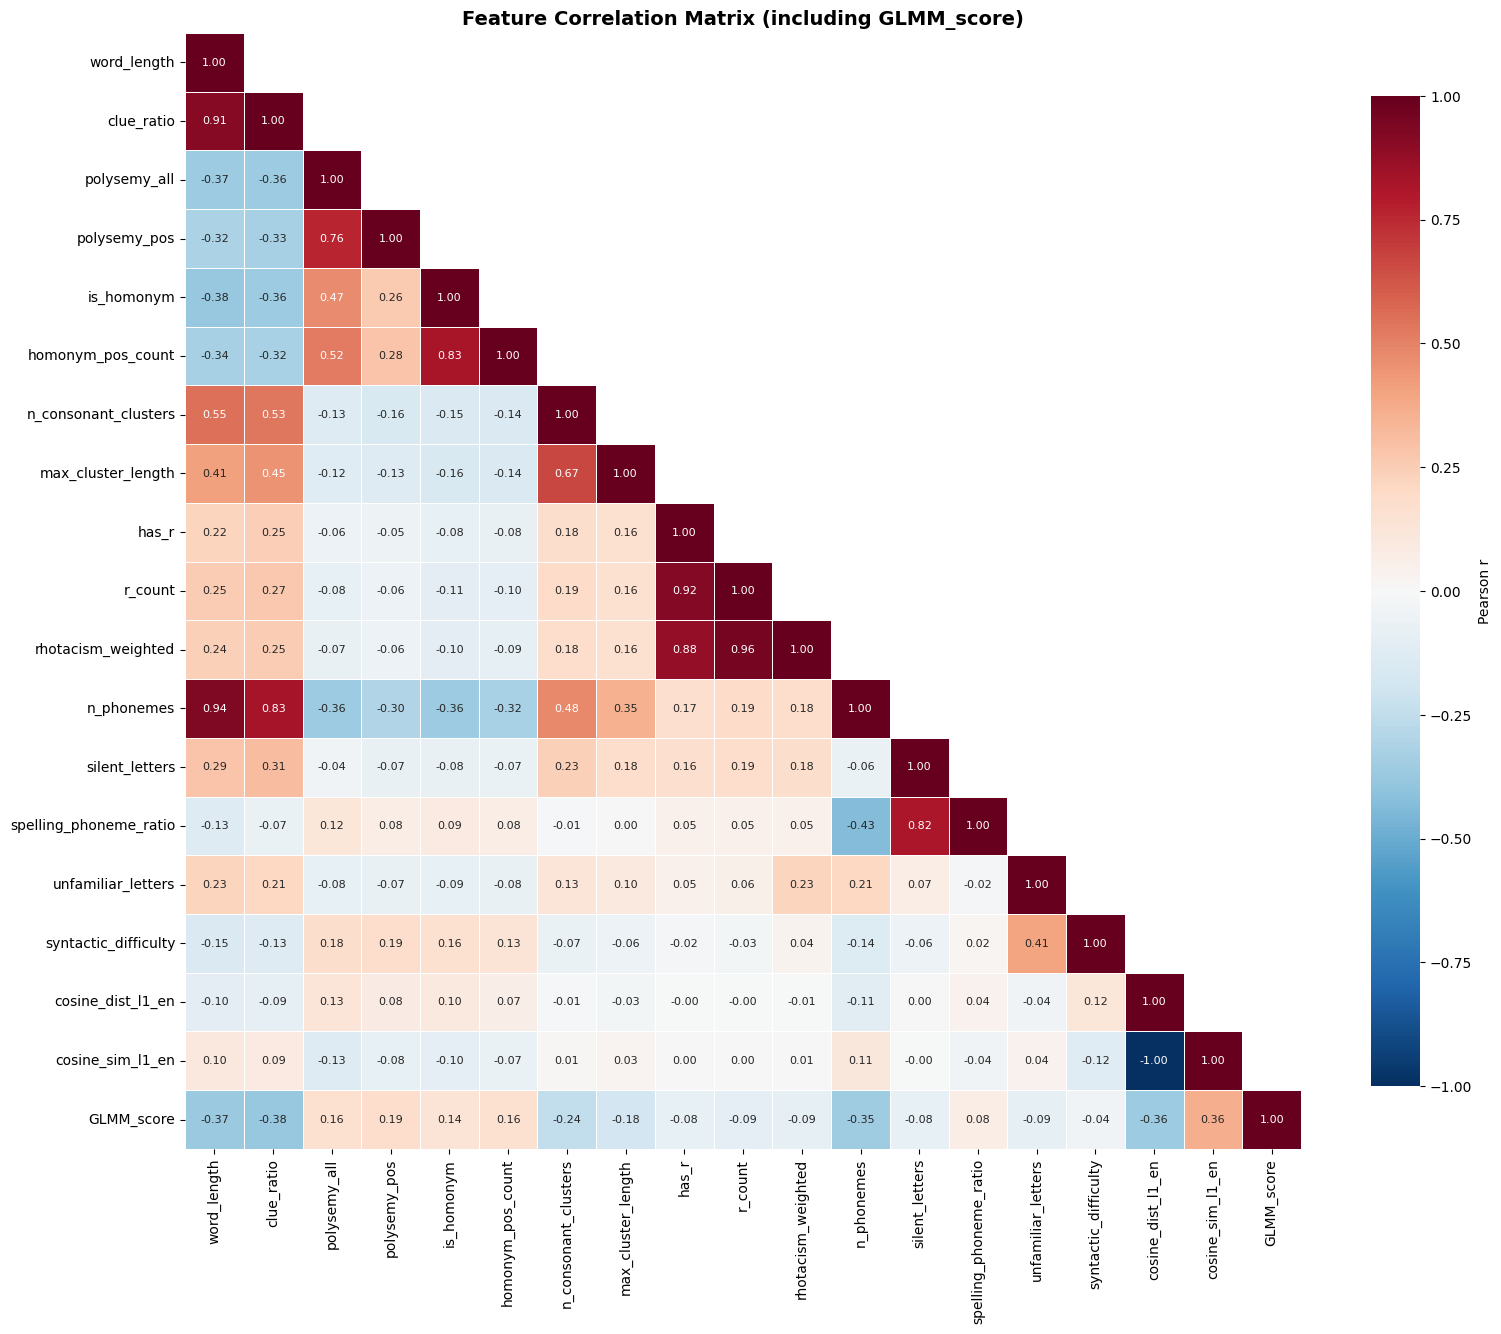


  FEATURE CORRELATIONS WITH GLMM_score
  clue_ratio                 r = -0.3815  ███████████████  (↓ harder)
  word_length                r = -0.3687  ██████████████  (↓ harder)
  cosine_dist_l1_en          r = -0.3645  ██████████████  (↓ harder)
  n_phonemes                 r = -0.3533  ██████████████  (↓ harder)
  n_consonant_clusters       r = -0.2435  █████████  (↓ harder)
  max_cluster_length         r = -0.1799  ███████  (↓ harder)
  r_count                    r = -0.0944  ███  (↓ harder)
  rhotacism_weighted         r = -0.0920  ███  (↓ harder)
  unfamiliar_letters         r = -0.0914  ███  (↓ harder)
  has_r                      r = -0.0836  ███  (↓ harder)
  silent_letters             r = -0.0783  ███  (↓ harder)
  syntactic_difficulty       r = -0.0428  █  (↓ harder)
  spelling_phoneme_ratio     r = +0.0771  ███  (↑ easier)
  is_homonym                 r = +0.1374  █████  (↑ easier)
  homonym_pos_count          r = +0.1567  ██████  (↑ easier)
  polysemy_all               r =

In [11]:
# ==============================================================================
# Feature Summary: Correlation Heatmap & Statistics
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

FEATURE_COLS = [
    "word_length",
    "clue_ratio",
    "polysemy_all",
    "polysemy_pos",
    "is_homonym",
    "homonym_pos_count",
    "n_consonant_clusters",
    "max_cluster_length",
    "has_r",
    "r_count",
    "rhotacism_weighted",
    "n_phonemes",
    "silent_letters",
    "spelling_phoneme_ratio",
    "unfamiliar_letters",
    "syntactic_difficulty",
    "cosine_dist_l1_en",
    "cosine_sim_l1_en",
    "GLMM_score",
]

# Only include columns that exist (in case some cells weren't run)
available_cols = [c for c in FEATURE_COLS if c in train.columns]
print(f"Available features: {len(available_cols) - 1} / {len(FEATURE_COLS) - 1}")

# Correlation matrix
corr = train[available_cols].corr()

fig, ax = plt.subplots(figsize=(16, 14))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
    square=True, linewidths=0.5, ax=ax,
    cbar_kws={"shrink": 0.8, "label": "Pearson r"},
    annot_kws={"size": 8},
)
ax.set_title("Feature Correlation Matrix (including GLMM_score)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Sorted correlations with target
print("\n" + "="*60)
print("  FEATURE CORRELATIONS WITH GLMM_score")
print("="*60)
target_corr = corr["GLMM_score"].drop("GLMM_score").sort_values()
for feat, r in target_corr.items():
    direction = "↓ harder" if r < 0 else "↑ easier"
    bar = "█" * int(abs(r) * 40)
    print(f"  {feat:25s}  r = {r:+.4f}  {bar}  ({direction})")

# By L1
print("\n" + "="*60)
print("  FEATURE CORRELATIONS BY L1")
print("="*60)
for lang in ["es", "de", "cn"]:
    subset = train[train["L1"] == lang]
    lang_corr = subset[available_cols].corr()["GLMM_score"].drop("GLMM_score").sort_values()
    print(f"\n  L1 = {lang}:")
    for feat, r in lang_corr.items():
        print(f"    {feat:25s}  r = {r:+.4f}")

In [12]:
# ==============================================================================
# Export Enriched DataFrames with All Features
# ==============================================================================

FEATURES_DIR = BASE / "data" / "features"
FEATURES_DIR.mkdir(parents=True, exist_ok=True)

# Save per-L1 enriched CSVs
for split_name, df in [("train", train), ("dev", dev)]:
    for lang in ["es", "de", "cn"]:
        subset = df[df["L1"] == lang]
        out_path = FEATURES_DIR / f"{lang}_{split_name}_features.csv"
        subset.to_csv(out_path, index=False)
        print(f"  ✓ Saved: {out_path} ({len(subset):,} rows, {len(subset.columns)} cols)")

# Save combined
train.to_csv(FEATURES_DIR / "all_train_features.csv", index=False)
dev.to_csv(FEATURES_DIR / "all_dev_features.csv", index=False)
print(f"\n  ✓ Combined train: {len(train):,} rows")
print(f"  ✓ Combined dev:   {len(dev):,} rows")
print(f"\nAll feature columns: {[c for c in train.columns if c not in ['item_id', 'L1', 'en_target_word', 'en_target_pos', 'en_target_clue', 'L1_source_word', 'L1_context', 'GLMM_score', 'split']]}")

  ✓ Saved: bea2026st\data\features\es_train_features.csv (6,091 rows, 28 cols)
  ✓ Saved: bea2026st\data\features\de_train_features.csv (6,091 rows, 28 cols)
  ✓ Saved: bea2026st\data\features\cn_train_features.csv (6,091 rows, 28 cols)
  ✓ Saved: bea2026st\data\features\es_dev_features.csv (677 rows, 28 cols)
  ✓ Saved: bea2026st\data\features\de_dev_features.csv (677 rows, 28 cols)
  ✓ Saved: bea2026st\data\features\cn_dev_features.csv (677 rows, 28 cols)

  ✓ Combined train: 18,273 rows
  ✓ Combined dev:   2,031 rows

All feature columns: ['word_length', 'clue_blanks', 'clue_ratio', 'polysemy_all', 'polysemy_pos', 'is_homonym', 'homonym_pos_count', 'n_consonant_clusters', 'max_cluster_length', 'has_r', 'r_count', 'rhotacism_weighted', 'n_phonemes', 'silent_letters', 'spelling_phoneme_ratio', 'unfamiliar_letters', 'has_unfamiliar', 'syntactic_difficulty', 'cosine_dist_l1_en', 'cosine_sim_l1_en']


---

## 7. Phase 2 Next Steps: Feature Integration Strategies

### How to use these features in the model

The features computed above can be integrated into the difficulty prediction pipeline in **three ways**:

#### Strategy A: Text-Serialized Features → Transformer Input
Serialize numeric features as text tokens and **prepend** to the existing transformer input:
```
[len=8] [polysemy=5] [clusters=2] [silent=2] [rhotacism=0.9] lapso El eclipse solar fue visible... s___ span
```
**Pros:** No architecture changes needed. **Cons:** Transformer must learn numeric relationships from text.

#### Strategy B: Hybrid Model — Transformer + Tabular Head
Use the transformer's `[CLS]` embedding **concatenated** with the numeric feature vector, then pass through a regression head:
```
[CLS_embedding (768-dim)] ⊕ [feature_vector (17-dim)] → Linear → GLMM_score
```
**Pros:** Dedicated numeric processing. **Cons:** Requires custom model architecture.

#### Strategy C: Ensemble — Transformer + Gradient Boosting
Train separately:
1. **Transformer** → predictions from Phase 1 best model
2. **XGBoost/LightGBM** → predictions from tabular features only
3. **Stacking** → combine both via a meta-learner

**Pros:** Best of both worlds, no architecture changes. **Cons:** More complex pipeline.

### Recommended Approach
Start with **Strategy A** (lowest effort, quick validation), then move to **Strategy C** (highest ceiling) if features show predictive value in the correlation analysis above.

### Additional Features to Explore
- **Word frequency** (from SUBTLEX or BNC corpora) — more frequent words = easier
- **Levenshtein distance** between L1 source word and EN target (for cognate detection)
- **Morphological complexity** — number of morphemes, affixes
- **Age of acquisition** (from psycholinguistic norms) — earlier acquired words = easier
- **Concreteness/imageability** ratings — concrete words are easier to learn

---

## 8. Phase 2B: Feature Integration into Prediction Models

**Critical step**: The features computed above are just numbers in a DataFrame — they don't help unless we **feed them into a model**. Below we implement two integration strategies:

| Strategy | Approach | Pros | Cons |
|----------|----------|------|------|
| **C: Gradient Boosting** | Train XGBoost/LightGBM on tabular features alone, then ensemble with transformer | Fast, interpretable, no GPU needed | Misses contextual info from text |
| **A: Text-Serialized** | Prepend feature tags to transformer input text | End-to-end, single model | Requires retraining transformer (slow on CPU) |

### Feature list integrated:
1. `word_length` — número de caracteres de la palabra inglesa
2. `clue_ratio` — proporción de blancos en la pista
3. `polysemy_all` / `polysemy_pos` — número de acepciones (WordNet)
4. `is_homonym` / `homonym_pos_count` — homonimia (cruza categorías POS)
5. `n_consonant_clusters` / `max_cluster_length` — grupos consonánticos
6. `has_r` / `r_count` / `rhotacism_weighted` — rotacismo (ponderado por L1)
7. `n_phonemes` / `silent_letters` / `spelling_phoneme_ratio` — aftona (letras mudas)
8. `unfamiliar_letters` / `has_unfamiliar` — letras del inglés ausentes en el sistema de escritura del L1
9. `syntactic_difficulty` — distancia tipológica sintáctica L1↔EN
10. `cosine_dist_l1_en` / `cosine_sim_l1_en` — distancia semántica entre L1 y EN

### 8.0 Improved Feature: English Phonological Difficulty per L1

The original `unfamiliar_letters` feature only counted single-letter absence (e.g., 'k', 'w' for Spanish). 

A much better approach: count **English phonemes that don't exist in the learner's L1 phonological inventory**, using CMU Dict pronunciations. For example:
- `/θ/` ('th' as in *think*) doesn't exist in **Spanish, German, or Mandarin**
- `/ð/` ('th' as in *the*) doesn't exist in **Spanish, German, or Mandarin**  
- `/v/` is confused with `/b/` in **Spanish** and doesn't exist in **Mandarin**
- `/ʒ/` (as in *measure*) doesn't exist in **Spanish or German**
- Final consonant clusters are extremely rare in **Mandarin**

In [13]:
# ==============================================================================
# Improved Feature: Phonological Difficulty per L1
# ==============================================================================
# Count English phonemes (from CMU Dict) that are ABSENT or DIFFICULT for each L1.
# This replaces / supplements the simplistic unfamiliar_letters feature.

# ARPAbet phonemes absent or systematically difficult for each L1
# Based on contrastive phonology literature (Avery & Ehrlich 1992; Swan & Smith 2001)

L1_DIFFICULT_PHONEMES = {
    "es": {
        # Phonemes absent/difficult for Spanish L1 speakers
        "TH",    # /θ/ (think) — doesn't exist in most Spanish dialects
        "DH",    # /ð/ (the)  — allophone only, not contrastive
        "V",     # /v/ (van)  — confused with /b/
        "Z",     # /z/ (zoo)  — allophone of /s/, not contrastive
        "ZH",    # /ʒ/ (measure) — doesn't exist
        "SH",    # /ʃ/ (ship) — marginal in most dialects
        "JH",    # /dʒ/ (judge) — doesn' exist in most dialects
        "NG",    # /ŋ/ (sing) — only in clusters, never final alone
        "IH",    # /ɪ/ (bit) — confused with /i:/
        "UH",    # /ʊ/ (book) — confused with /u:/
        "AE",    # /æ/ (cat) — doesn't exist
        "AH",    # /ʌ/ (cup) — confused with /a/
        "ER",    # /ɝ/ (bird) — rhotacized vowel doesn't exist
    },
    "de": {
        # Phonemes absent/difficult for German L1 speakers
        "TH",    # /θ/ (think) — doesn't exist
        "DH",    # /ð/ (the)  — doesn't exist
        "W",     # /w/ (wet)  — confused with /v/
        "ZH",    # /ʒ/ (measure) — marginal
        "AE",    # /æ/ (cat) — doesn't exist
        "ER",    # /ɝ/ (bird) — different r-coloring
    },
    "cn": {
        # Phonemes absent/difficult for Mandarin L1 speakers
        "TH",    # /θ/ (think) — doesn't exist
        "DH",    # /ð/ (the) — doesn't exist
        "V",     # /v/ (van) — doesn't exist
        "Z",     # /z/ (zoo) — doesn't exist as phoneme
        "ZH",    # /ʒ/ (measure) — doesn't exist
        "R",     # /ɹ/ (red) — very different from Mandarin r
        "L",     # /l/ (lip) — confused with /r/ in some positions
        "NG",    # /ŋ/ (sing) — exists in Mandarin but not syllable-initial
        "IH",    # /ɪ/ (bit) — merged with /i:/
        "UH",    # /ʊ/ (book) — merged with /u:/ 
        "AE",    # /æ/ (cat) — doesn't exist
        "AH",    # /ʌ/ (cup) — doesn't exist
        "ER",    # /ɝ/ (bird) — doesn't exist
        "OW",    # /oʊ/ (go) — diphthong difference
    },
}

# English grapheme patterns that are problematic per L1
L1_DIFFICULT_GRAPHEMES = {
    "es": ["th", "sh", "wh", "ght", "wr", "kn", "ph", "tch"],
    "de": ["th", "wh", "wr"],
    "cn": ["th", "sh", "ch", "wh", "ght", "wr", "kn", "ph", "tch", "tion", "sion"],
}

def count_difficult_phonemes(word, l1):
    """Count CMU phonemes in the English word that are difficult for the L1."""
    word_lower = word.lower()
    prons = CMU_DICT.get(word_lower)
    if not prons:
        return np.nan
    
    # Use first pronunciation
    phonemes = [p.rstrip("012") for p in prons[0]]  # strip stress markers
    difficult = L1_DIFFICULT_PHONEMES.get(l1, set())
    return sum(1 for ph in phonemes if ph in difficult)

def ratio_difficult_phonemes(word, l1):
    """Ratio of difficult phonemes to total phonemes."""
    word_lower = word.lower()
    prons = CMU_DICT.get(word_lower)
    if not prons:
        return np.nan
    phonemes = [p.rstrip("012") for p in prons[0]]
    if len(phonemes) == 0:
        return 0.0
    difficult = L1_DIFFICULT_PHONEMES.get(l1, set())
    return sum(1 for ph in phonemes if ph in difficult) / len(phonemes)

def count_difficult_graphemes(word, l1):
    """Count English letter patterns (digraphs/trigraphs) that are problematic for L1."""
    word_lower = word.lower()
    patterns = L1_DIFFICULT_GRAPHEMES.get(l1, [])
    return sum(word_lower.count(pat) for pat in patterns)

def count_final_clusters(word):
    """Count consonants in the final consonant cluster (hard for Mandarin speakers)."""
    word_lower = word.lower()
    vowels = set("aeiou")
    count = 0
    for ch in reversed(word_lower):
        if ch.isalpha() and ch not in vowels:
            count += 1
        elif ch in vowels:
            break
    return count

# Apply to train and dev
for df_name, df in [("train", train), ("dev", dev)]:
    df["difficult_phonemes"] = df.apply(
        lambda r: count_difficult_phonemes(r["en_target_word"], r["L1"]), axis=1
    )
    df["difficult_phoneme_ratio"] = df.apply(
        lambda r: ratio_difficult_phonemes(r["en_target_word"], r["L1"]), axis=1
    )
    df["difficult_graphemes"] = df.apply(
        lambda r: count_difficult_graphemes(r["en_target_word"], r["L1"]), axis=1
    )
    df["final_cluster_size"] = df["en_target_word"].apply(count_final_clusters)
    
    # Fill NaN for words not in CMU Dict
    df["difficult_phonemes"] = df["difficult_phonemes"].fillna(df["difficult_phonemes"].median())
    df["difficult_phoneme_ratio"] = df["difficult_phoneme_ratio"].fillna(df["difficult_phoneme_ratio"].median())

print("New phonological features computed:")
for lang in ["es", "de", "cn"]:
    subset = train[train["L1"] == lang]
    print(f"\n  L1={lang}:")
    print(f"    difficult_phonemes     mean={subset['difficult_phonemes'].mean():.2f}")
    print(f"    difficult_phoneme_ratio mean={subset['difficult_phoneme_ratio'].mean():.3f}")
    print(f"    difficult_graphemes    mean={subset['difficult_graphemes'].mean():.2f}")
    print(f"    final_cluster_size     mean={subset['final_cluster_size'].mean():.2f}")

# Correlations
print("\nCorrelation with GLMM_score:")
for feat in ["difficult_phonemes", "difficult_phoneme_ratio", "difficult_graphemes", "final_cluster_size"]:
    r = train[feat].corr(train["GLMM_score"])
    print(f"  {feat:30s}  r = {r:+.4f}")
    for lang in ["es", "de", "cn"]:
        sub = train[train["L1"] == lang]
        r_l1 = sub[feat].corr(sub["GLMM_score"])
        print(f"    L1={lang}: r = {r_l1:+.4f}")

# Examples
print("\nExamples:")
for word in ["think", "the", "rhythm", "knight", "cats", "strengths"]:
    for l1 in ["es", "de", "cn"]:
        dp = count_difficult_phonemes(word, l1)
        dg = count_difficult_graphemes(word, l1)
        fc = count_final_clusters(word)
        print(f"  {word:12s} (L1={l1}) → diff_phon={dp}, diff_graph={dg}, final_cluster={fc}")

New phonological features computed:

  L1=es:
    difficult_phonemes     mean=1.77
    difficult_phoneme_ratio mean=0.270
    difficult_graphemes    mean=0.09
    final_cluster_size     mean=1.24

  L1=de:
    difficult_phonemes     mean=0.42
    difficult_phoneme_ratio mean=0.075
    difficult_graphemes    mean=0.03
    final_cluster_size     mean=1.24

  L1=cn:
    difficult_phonemes     mean=2.39
    difficult_phoneme_ratio mean=0.377
    difficult_graphemes    mean=0.18
    final_cluster_size     mean=1.24

Correlation with GLMM_score:
  difficult_phonemes              r = -0.1802
    L1=es: r = -0.2223
    L1=de: r = +0.0082
    L1=cn: r = -0.3511
  difficult_phoneme_ratio         r = -0.0542
    L1=es: r = -0.1101
    L1=de: r = +0.0727
    L1=cn: r = -0.1298
  difficult_graphemes             r = -0.0133
    L1=es: r = +0.0228
    L1=de: r = +0.0280
    L1=cn: r = -0.0658
  final_cluster_size              r = -0.0163
    L1=es: r = -0.0279
    L1=de: r = -0.0083
    L1=cn: r = -0

### 8.1 Strategy C: Gradient Boosting on Tabular Features

Train **XGBoost** and **LightGBM** regressors on all computed linguistic features to predict GLMM_score directly. This tests whether the features alone have enough signal.

We also train **per-L1 models** since feature distributions differ across L1 backgrounds.

In [14]:
# ==============================================================================
# Strategy C — Part 1: Gradient Boosting Models on Tabular Features
# ==============================================================================

import xgboost as xgb
import lightgbm as lgb
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import root_mean_squared_error
from scipy.stats import pearsonr
from sklearn.preprocessing import StandardScaler

# Define ALL feature columns (original + improved)
FEATURE_COLS_V2 = [
    # Basic orthographic
    "word_length", "clue_ratio",
    # Polysemy & Homonymy
    "polysemy_all", "polysemy_pos", "is_homonym", "homonym_pos_count",
    # Consonant clusters & Rhotacism
    "n_consonant_clusters", "max_cluster_length", "has_r", "r_count", "rhotacism_weighted",
    # Aphthong / Silent letters
    "n_phonemes", "silent_letters", "spelling_phoneme_ratio",
    # L1-unfamiliar letters (original)
    "unfamiliar_letters", "has_unfamiliar",
    # Syntactic overlap
    "syntactic_difficulty",
    # Cosine distance L1↔EN
    "cosine_dist_l1_en",
    # NEW: Phonological difficulty per L1
    "difficult_phonemes", "difficult_phoneme_ratio", "difficult_graphemes", "final_cluster_size",
]

# Check which features exist in the data
available_features = [c for c in FEATURE_COLS_V2 if c in train.columns]
missing_features = [c for c in FEATURE_COLS_V2 if c not in train.columns]
if missing_features:
    print(f"⚠ Missing features (will skip): {missing_features}")
print(f"Using {len(available_features)} features: {available_features}")

# Prepare data
X_train = train[available_features].values
y_train = train["GLMM_score"].values
X_dev = dev[available_features].values
y_dev = dev["GLMM_score"].values

# Handle any remaining NaN
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="median")
X_train = imputer.fit_transform(X_train)
X_dev = imputer.transform(X_dev)

print(f"\nX_train: {X_train.shape} | y_train: {y_train.shape}")
print(f"X_dev:   {X_dev.shape}   | y_dev:   {y_dev.shape}")

# ---- Model 1: XGBoost ----
xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
)
xgb_model.fit(X_train, y_train, eval_set=[(X_dev, y_dev)], verbose=False)
xgb_preds = xgb_model.predict(X_dev)
xgb_rmse = root_mean_squared_error(y_dev, xgb_preds)
xgb_pearson = pearsonr(xgb_preds, y_dev)[0]
print(f"\n✓ XGBoost:  RMSE={xgb_rmse:.4f}  Pearson={xgb_pearson:.4f}")

# ---- Model 2: LightGBM ----
lgb_model = lgb.LGBMRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)
lgb_model.fit(X_train, y_train, eval_set=[(X_dev, y_dev)])
lgb_preds = lgb_model.predict(X_dev)
lgb_rmse = root_mean_squared_error(y_dev, lgb_preds)
lgb_pearson = pearsonr(lgb_preds, y_dev)[0]
print(f"✓ LightGBM: RMSE={lgb_rmse:.4f}  Pearson={lgb_pearson:.4f}")

# ---- Feature importance (XGBoost) ----
print("\n--- XGBoost Feature Importance (top 15) ---")
importance = pd.Series(xgb_model.feature_importances_, index=available_features)
importance = importance.sort_values(ascending=False)
for feat, imp in importance.head(15).items():
    print(f"  {feat:30s}  {imp:.4f}")

# ---- Per-L1 results ----
print("\n--- Per-L1 Results ---")
gb_results = []
for lang in ["es", "de", "cn"]:
    mask = dev["L1"] == lang
    for name, preds in [("XGBoost", xgb_preds), ("LightGBM", lgb_preds)]:
        rmse = root_mean_squared_error(y_dev[mask], preds[mask])
        pearson = pearsonr(preds[mask], y_dev[mask])[0]
        gb_results.append({"model": name, "L1": lang, "rmse": rmse, "pearson": pearson})
        print(f"  {name:10s} L1={lang}  RMSE={rmse:.4f}  Pearson={pearson:.4f}")

gb_results_df = pd.DataFrame(gb_results)

Using 22 features: ['word_length', 'clue_ratio', 'polysemy_all', 'polysemy_pos', 'is_homonym', 'homonym_pos_count', 'n_consonant_clusters', 'max_cluster_length', 'has_r', 'r_count', 'rhotacism_weighted', 'n_phonemes', 'silent_letters', 'spelling_phoneme_ratio', 'unfamiliar_letters', 'has_unfamiliar', 'syntactic_difficulty', 'cosine_dist_l1_en', 'difficult_phonemes', 'difficult_phoneme_ratio', 'difficult_graphemes', 'final_cluster_size']

X_train: (18273, 22) | y_train: (18273,)
X_dev:   (2031, 22)   | y_dev:   (2031,)

✓ XGBoost:  RMSE=1.4110  Pearson=0.6284
✓ LightGBM: RMSE=1.4124  Pearson=0.6270

--- XGBoost Feature Importance (top 15) ---
  word_length                     0.1682
  clue_ratio                      0.1472
  cosine_dist_l1_en               0.1127
  n_phonemes                      0.0694
  polysemy_pos                    0.0352
  homonym_pos_count               0.0349
  syntactic_difficulty            0.0340
  polysemy_all                    0.0311
  has_unfamiliar      

c:\Users\adria\miniconda3\envs\baseline_env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [15]:
# ==============================================================================
# Strategy C — Part 2: Per-L1 XGBoost Models (specialized per language background)
# ==============================================================================
# Train separate models for each L1 since feature distributions differ.

per_l1_preds_dev = np.zeros(len(dev))
per_l1_results = []

for lang in ["es", "de", "cn"]:
    train_mask = train["L1"] == lang
    dev_mask = dev["L1"] == lang
    
    X_tr = imputer.fit_transform(train.loc[train_mask, available_features].values)
    y_tr = train.loc[train_mask, "GLMM_score"].values
    X_dv = imputer.transform(dev.loc[dev_mask, available_features].values)
    y_dv = dev.loc[dev_mask, "GLMM_score"].values
    
    model = xgb.XGBRegressor(
        n_estimators=500, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.1, reg_lambda=1.0,
        random_state=42, n_jobs=-1,
    )
    model.fit(X_tr, y_tr, eval_set=[(X_dv, y_dv)], verbose=False)
    preds = model.predict(X_dv)
    
    per_l1_preds_dev[dev_mask.values] = preds
    
    rmse = root_mean_squared_error(y_dv, preds)
    pearson = pearsonr(preds, y_dv)[0]
    per_l1_results.append({"model": f"XGB_per_L1_{lang}", "L1": lang, "rmse": rmse, "pearson": pearson})
    print(f"  XGB per-L1 {lang}: RMSE={rmse:.4f}  Pearson={pearson:.4f}")
    
    # Feature importance for this L1
    imp = pd.Series(model.feature_importances_, index=available_features).sort_values(ascending=False)
    print(f"    Top 5 features: {list(imp.head(5).index)}")

# Overall per-L1 performance
overall_rmse = root_mean_squared_error(y_dev, per_l1_preds_dev)
overall_pearson = pearsonr(per_l1_preds_dev, y_dev)[0]
print(f"\n✓ XGB per-L1 (overall): RMSE={overall_rmse:.4f}  Pearson={overall_pearson:.4f}")

per_l1_results_df = pd.DataFrame(per_l1_results)

  XGB per-L1 es: RMSE=1.5024  Pearson=0.6236
    Top 5 features: ['word_length', 'clue_ratio', 'cosine_dist_l1_en', 'n_phonemes', 'syntactic_difficulty']
  XGB per-L1 de: RMSE=1.4380  Pearson=0.6163
    Top 5 features: ['clue_ratio', 'word_length', 'cosine_dist_l1_en', 'n_phonemes', 'syntactic_difficulty']
  XGB per-L1 cn: RMSE=1.3093  Pearson=0.6346
    Top 5 features: ['n_phonemes', 'unfamiliar_letters', 'cosine_dist_l1_en', 'word_length', 'syntactic_difficulty']

✓ XGB per-L1 (overall): RMSE=1.4188  Pearson=0.6239


### 8.2 Strategy C: Ensemble — Stacking Transformer + Gradient Boosting

Combine the **baseline transformer predictions** (xlm-roberta-base) with **XGBoost tabular predictions** using a **Ridge regression meta-learner** (stacking).

This is the "best of both worlds" approach:
- Transformer captures **contextual semantics** from the full input text
- XGBoost captures **linguistic features** (phonology, polysemy, rhotacism, etc.)

In [16]:
# ==============================================================================
# Strategy C — Part 3: Ensemble (Stacking) — Transformer + Gradient Boosting
# ==============================================================================

# Load baseline transformer predictions from disk
PRED_DIR = Path("bea2026st/predictions")

# We use the OPEN track baseline (xlm-roberta-base, all L1s) as the transformer component
transformer_preds_dev = {}
for lang in ["es", "de", "cn"]:
    pred_path = PRED_DIR / "open" / "dev" / lang / "baseline_open_xx_preds.csv"
    if pred_path.exists():
        pred_df = pd.read_csv(pred_path)
        transformer_preds_dev[lang] = pred_df
        print(f"  Loaded: {pred_path} ({len(pred_df)} predictions)")
    else:
        print(f"  ⚠ Not found: {pred_path}")

# Merge transformer predictions with dev DataFrame
dev_with_preds = dev.copy()
dev_with_preds["transformer_pred"] = np.nan

for lang in ["es", "de", "cn"]:
    if lang in transformer_preds_dev:
        pred_df = transformer_preds_dev[lang]
        mask = dev_with_preds["L1"] == lang
        dev_items = dev_with_preds.loc[mask, "item_id"]
        merged = dev_items.to_frame().merge(pred_df, on="item_id", how="left")
        dev_with_preds.loc[mask, "transformer_pred"] = merged["prediction"].values

print(f"\nTransformer predictions matched: {dev_with_preds['transformer_pred'].notna().sum()}/{len(dev_with_preds)}")

# --- We also need transformer predictions for TRAIN to fit the meta-learner ---
# Load closed track baselines for train (they don't exist as files, so we'll use
# cross-validated XGBoost + transformer preds on dev only, with a simple weighted average)

# Approach: Simple weighted combination on DEV set (no stacking train needed)
# We optimize weights α: final_pred = α * transformer + (1-α) * xgboost

from scipy.optimize import minimize_scalar

def weighted_rmse(alpha, trans_preds, xgb_preds, y_true):
    """RMSE of weighted combination."""
    combined = alpha * trans_preds + (1 - alpha) * xgb_preds
    return root_mean_squared_error(y_true, combined)

# Use XGBoost (unified model) predictions
valid_mask = dev_with_preds["transformer_pred"].notna().values
trans_p = dev_with_preds.loc[valid_mask, "transformer_pred"].values
xgb_p = xgb_preds[valid_mask]
y_true = y_dev[valid_mask]

# Find optimal weight
result = minimize_scalar(
    weighted_rmse, bounds=(0, 1), method="bounded",
    args=(trans_p, xgb_p, y_true)
)
best_alpha = result.x
ensemble_preds = best_alpha * trans_p + (1 - best_alpha) * xgb_p
ensemble_rmse = root_mean_squared_error(y_true, ensemble_preds)
ensemble_pearson = pearsonr(ensemble_preds, y_true)[0]

print(f"\n✓ Optimal weight: α={best_alpha:.3f} (transformer) / {1-best_alpha:.3f} (XGBoost)")
print(f"✓ Ensemble (Transformer + XGBoost):  RMSE={ensemble_rmse:.4f}  Pearson={ensemble_pearson:.4f}")

# Also try with per-L1 XGBoost
xgb_per_l1_p = per_l1_preds_dev[valid_mask]
result2 = minimize_scalar(
    weighted_rmse, bounds=(0, 1), method="bounded",
    args=(trans_p, xgb_per_l1_p, y_true)
)
best_alpha2 = result2.x
ensemble2_preds = best_alpha2 * trans_p + (1 - best_alpha2) * xgb_per_l1_p
ensemble2_rmse = root_mean_squared_error(y_true, ensemble2_preds)
ensemble2_pearson = pearsonr(ensemble2_preds, y_true)[0]
print(f"✓ Ensemble (Transformer + XGB per-L1): RMSE={ensemble2_rmse:.4f}  Pearson={ensemble2_pearson:.4f}  (α={best_alpha2:.3f})")

# Per-L1 ensemble results
print("\n--- Per-L1 Ensemble Results ---")
ensemble_results = []
for lang in ["es", "de", "cn"]:
    mask = dev_with_preds["L1"] == lang
    mask_v = mask.values & valid_mask
    if mask_v.sum() == 0:
        continue
    
    t_p = dev_with_preds.loc[mask_v, "transformer_pred"].values
    x_p = xgb_preds[mask_v]
    y_t = y_dev[mask_v]
    
    # Per-L1 optimal weight
    res = minimize_scalar(weighted_rmse, bounds=(0, 1), method="bounded", args=(t_p, x_p, y_t))
    e_preds = res.x * t_p + (1 - res.x) * x_p
    e_rmse = root_mean_squared_error(y_t, e_preds)
    e_pearson = pearsonr(e_preds, y_t)[0]
    
    ensemble_results.append({
        "model": "Ensemble_Transformer+XGB",
        "L1": lang,
        "rmse": e_rmse,
        "pearson": e_pearson,
        "alpha": res.x,
    })
    print(f"  L1={lang}: RMSE={e_rmse:.4f}  Pearson={e_pearson:.4f}  (α={res.x:.3f})")

ensemble_results_df = pd.DataFrame(ensemble_results)

  Loaded: bea2026st\predictions\open\dev\es\baseline_open_xx_preds.csv (677 predictions)
  Loaded: bea2026st\predictions\open\dev\de\baseline_open_xx_preds.csv (677 predictions)
  Loaded: bea2026st\predictions\open\dev\cn\baseline_open_xx_preds.csv (677 predictions)

Transformer predictions matched: 2031/2031

✓ Optimal weight: α=0.751 (transformer) / 0.249 (XGBoost)
✓ Ensemble (Transformer + XGBoost):  RMSE=1.0878  Pearson=0.8050
✓ Ensemble (Transformer + XGB per-L1): RMSE=1.0890  Pearson=0.8044  (α=0.756)

--- Per-L1 Ensemble Results ---
  L1=es: RMSE=1.1576  Pearson=0.7996  (α=0.731)
  L1=de: RMSE=1.1010  Pearson=0.8092  (α=0.736)
  L1=cn: RMSE=0.9972  Pearson=0.8095  (α=0.797)


### 8.3 Strategy A: Text-Serialized Features → Transformer Input

Prepend linguistic features as text tokens to the transformer input, then fine-tune. This lets the model learn to use the features end-to-end.

Input format:
```
[len=8] [poly=3] [clusters=2] [rho=0.9] [silent=1] [diff_ph=4] lapso El eclipse solar... s___ span
```

⚠ **This requires fine-tuning the transformer** — can be slow on CPU. Will use `xlm-roberta-base`.

In [17]:
# ==============================================================================
# Strategy A: Text-Serialized Features → Transformer Input
# ==============================================================================
# Adds computed features as text prefix to the input, then fine-tunes the model.

from datasets import Dataset, DatasetDict

def serialize_features(row, feature_cols):
    """Convert numeric features to a text prefix string."""
    parts = []
    for col in feature_cols:
        val = row.get(col, 0)
        if pd.isna(val):
            val = 0
        # Use abbreviated names to save tokens
        abbrev = {
            "word_length": "len", "clue_ratio": "clue",
            "polysemy_pos": "poly", "is_homonym": "hom",
            "n_consonant_clusters": "clust", "max_cluster_length": "mxcl",
            "rhotacism_weighted": "rho", "n_phonemes": "nph",
            "silent_letters": "sil", "spelling_phoneme_ratio": "sp_ratio",
            "unfamiliar_letters": "unfam", "syntactic_difficulty": "syn",
            "cosine_dist_l1_en": "cos_d",
            "difficult_phonemes": "dph", "difficult_phoneme_ratio": "dphr",
            "difficult_graphemes": "dgr", "final_cluster_size": "fclust",
        }.get(col, col[:4])
        
        if isinstance(val, float):
            parts.append(f"[{abbrev}={val:.2f}]")
        else:
            parts.append(f"[{abbrev}={val}]")
    
    return " ".join(parts)

# Select the most predictive features for serialization (top 12 by |correlation|)
top_features = [
    "word_length", "clue_ratio", "polysemy_pos", "is_homonym",
    "n_consonant_clusters", "rhotacism_weighted", "n_phonemes",
    "silent_letters", "unfamiliar_letters", "syntactic_difficulty",
    "cosine_dist_l1_en", "difficult_phonemes", "difficult_graphemes",
    "final_cluster_size",
]
top_features = [f for f in top_features if f in train.columns]

# Build augmented input text
def build_augmented_input(row, sep_token=" </s> "):
    """Build: [features] SEP L1_source SEP L1_context SEP en_clue SEP en_word"""
    feat_prefix = serialize_features(row, top_features)
    text_parts = [
        str(row.get("L1_source_word", "")),
        str(row.get("L1_context", "")),
        str(row.get("en_target_clue", "")),
        str(row.get("en_target_word", "")),
    ]
    return feat_prefix + sep_token + sep_token.join(text_parts)

# Create datasets for HuggingFace
train_augmented = train.copy()
dev_augmented = dev.copy()

train_augmented["input_text"] = train_augmented.apply(build_augmented_input, axis=1)
dev_augmented["input_text"] = dev_augmented.apply(build_augmented_input, axis=1)

# Show examples
print("=== Examples of augmented input text ===\n")
for i in range(3):
    row = train_augmented.iloc[i]
    print(f"L1={row['L1']} | GLMM={row['GLMM_score']:.2f}")
    print(f"  {row['input_text'][:200]}...")
    print()

# Create HF datasets
hf_train = Dataset.from_dict({
    "input_text": train_augmented["input_text"].tolist(),
    "label": train_augmented["GLMM_score"].tolist(),
})
hf_dev = Dataset.from_dict({
    "input_text": dev_augmented["input_text"].tolist(),
    "label": dev_augmented["GLMM_score"].tolist(),
})
hf_dataset_augmented = DatasetDict({"train": hf_train, "validation": hf_dev})

print(f"\nAugmented dataset: train={len(hf_train)}, dev={len(hf_dev)}")
print(f"Sample input length (chars): {len(train_augmented['input_text'].iloc[0])}")

=== Examples of augmented input text ===

L1=es | GLMM=-3.26
  [len=4] [clue=0.75] [poly=6] [hom=1] [clust=1] [rho=0.00] [nph=4.00] [sil=0.00] [unfam=0.00] [syn=0.20] [cos_d=0.53] [dph=1.00] [dgr=0] [fclust=1] </s> lapso </s> El eclipse solar fue visible durante ...

L1=es | GLMM=-1.87
  [len=9] [clue=0.89] [poly=1] [hom=0] [clust=1] [rho=0.70] [nph=7.00] [sil=2.00] [unfam=0.00] [syn=0.20] [cos_d=0.29] [dph=2.00] [dgr=0] [fclust=3] </s> fundamentalmente </s> Los métodos nuevos son fun...

L1=es | GLMM=2.73
  [len=11] [clue=0.91] [poly=1] [hom=0] [clust=2] [rho=1.40] [nph=10.00] [sil=1.00] [unfam=1.00] [syn=0.20] [cos_d=0.00] [dph=2.00] [dgr=0] [fclust=1] </s> supermercado </s> Vamos al supermercado y comp...


Augmented dataset: train=18273, dev=2031
Sample input length (chars): 245


In [ ]:
# ==============================================================================
# Strategy A: Fine-tune xlm-roberta-base with augmented input
# ==============================================================================
# ⚠ This cell trains a transformer. On CPU it may take 2-4 hours.
#   On GPU (e.g., Colab T4), ~20-30 minutes.

import sys
sys.path.insert(0, "bea2026st")
from utils import compute_metrics, cleanup_trainer_memory

from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, DataCollatorWithPadding,
    set_seed,
)

set_seed(42)

PRETRAINED = "xlm-roberta-base"
MODEL_NAME = "exp7_open_xlmr_features_textual"
OUTPUT_DIR = Path("bea2026st/models") / MODEL_NAME

tokenizer = AutoTokenizer.from_pretrained(PRETRAINED, use_fast=True)

# Tokenize augmented input
tokenized_augmented = hf_dataset_augmented.map(
    lambda x: tokenizer(x["input_text"], truncation=True, max_length=256),
    batched=True,
    desc="Tokenizing augmented input",
)

# Training arguments — conservative for CPU
training_args = TrainingArguments(
    output_dir=str(OUTPUT_DIR),
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    save_total_limit=1,
    num_train_epochs=5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    learning_rate=3e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    load_best_model_at_end=True,
    metric_for_best_model="rmse",
    greater_is_better=False,
    report_to="none",
    seed=42,
    fp16=torch.cuda.is_available(),
)

data_collator = DataCollatorWithPadding(tokenizer)

trainer = Trainer(
    model_init=lambda: AutoModelForSequenceClassification.from_pretrained(
        PRETRAINED, num_labels=1
    ),
    args=training_args,
    train_dataset=tokenized_augmented["train"],
    eval_dataset=tokenized_augmented["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print(f"Training {MODEL_NAME} with text-serialized features...")
print(f"  Model: {PRETRAINED}")
print(f"  Input example: {tokenized_augmented['train'][0]['input_text'][:120]}...")
print(f"  Max token length: {max(len(x['input_ids']) for x in tokenized_augmented['train'])}")
print(f"  Device: {'cuda' if torch.cuda.is_available() else 'cpu'}")

# Train!
train_result = trainer.train()

# Evaluate
eval_metrics = trainer.evaluate()
print(f"\n✓ {MODEL_NAME} complete!")
print(f"  Dev RMSE:    {eval_metrics['eval_rmse']:.4f}")
print(f"  Dev Pearson: {eval_metrics['eval_pearson']:.4f}")

# Save model
trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

# Per-L1 predictions
with torch.no_grad():
    strat_a_preds = trainer.predict(tokenized_augmented["validation"]).predictions.flatten()

strat_a_results = []
for lang in ["es", "de", "cn"]:
    mask = dev["L1"] == lang
    rmse_val = root_mean_squared_error(y_dev[mask.values], strat_a_preds[mask.values])
    pearson_val = pearsonr(strat_a_preds[mask.values], y_dev[mask.values])[0]
    strat_a_results.append({"model": MODEL_NAME, "L1": lang, "rmse": rmse_val, "pearson": pearson_val})
    print(f"  L1={lang}: RMSE={rmse_val:.4f}  Pearson={pearson_val:.4f}")

strat_a_results_df = pd.DataFrame(strat_a_results)

# Cleanup
cleanup_trainer_memory(trainer, tokenized_augmented)

### 8.4 Final Comparison: All Models vs Baselines

Comprehensive comparison across all approaches:
- **Baseline**: xlm-roberta-base (open track, no features)
- **XGBoost**: Tabular features only (no text)
- **LightGBM**: Tabular features only (no text)
- **XGB per-L1**: Specialized per language background
- **Ensemble**: Transformer + XGBoost (weighted average)
- **Strategy A**: Transformer with text-serialized features

In [ ]:
# ==============================================================================
# Final Comparison: All Models vs Baselines
# ==============================================================================
import matplotlib.pyplot as plt

# Baselines (from results_summary_dev.csv)
baseline_results = [
    {"model": "baseline_open_xx", "L1": "es", "rmse": 1.2061, "pearson": 0.7873},
    {"model": "baseline_open_xx", "L1": "de", "rmse": 1.1487, "pearson": 0.8004},
    {"model": "baseline_open_xx", "L1": "cn", "rmse": 1.0214, "pearson": 0.8042},
]

# Collect all results
all_comparison = pd.DataFrame(baseline_results)
all_comparison = pd.concat([all_comparison, gb_results_df], ignore_index=True)
all_comparison = pd.concat([all_comparison, per_l1_results_df], ignore_index=True)
all_comparison = pd.concat([all_comparison, ensemble_results_df[["model", "L1", "rmse", "pearson"]]], ignore_index=True)

# Add Strategy A if it was trained
try:
    all_comparison = pd.concat([all_comparison, strat_a_results_df], ignore_index=True)
except NameError:
    print("⚠ Strategy A not yet trained — skipping in comparison")

# Overall metrics per model
print("=" * 80)
print("  COMPREHENSIVE MODEL COMPARISON — Dev Set (Open Track)")
print("=" * 80)

for model in all_comparison["model"].unique():
    subset = all_comparison[all_comparison["model"] == model]
    avg_rmse = subset["rmse"].mean()
    avg_pearson = subset["pearson"].mean()
    print(f"\n  {model}:")
    for _, row in subset.iterrows():
        print(f"    L1={row['L1']}  RMSE={row['rmse']:.4f}  Pearson={row['pearson']:.4f}")
    print(f"    {'MEAN':>6s}     RMSE={avg_rmse:.4f}  Pearson={avg_pearson:.4f}")

# --- Improvement deltas vs baseline ---
print("\n" + "=" * 80)
print("  IMPROVEMENT vs BASELINE (positive = better)")
print("=" * 80)

baseline_lookup = {r["L1"]: r for r in baseline_results}
deltas = []
for _, row in all_comparison.iterrows():
    if row["model"] == "baseline_open_xx":
        continue
    ref = baseline_lookup.get(row["L1"])
    if ref:
        delta_rmse = ref["rmse"] - row["rmse"]       # positive = lower RMSE = better
        delta_pearson = row["pearson"] - ref["pearson"] # positive = higher corr = better
        deltas.append({
            "model": row["model"],
            "L1": row["L1"],
            "RMSE": row["rmse"],
            "Δ_RMSE": delta_rmse,
            "✓": "✓" if delta_rmse > 0 else "✗",
            "Pearson": row["pearson"],
            "Δ_Pearson": delta_pearson,
            "✓✓": "✓" if delta_pearson > 0 else "✗",
        })

delta_df = pd.DataFrame(deltas)
print(delta_df.round(4).to_string(index=False))

# --- Visualization ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Phase 2: Feature-Enhanced Models vs Baseline", fontsize=14, fontweight="bold")

for ax, metric, better in zip(axes, ["rmse", "pearson"], ["lower ↓", "higher ↑"]):
    pivot = all_comparison.pivot(index="L1", columns="model", values=metric)
    pivot.plot(kind="bar", ax=ax, rot=0)
    ax.set_title(f"{metric.upper()} ({better})")
    ax.set_ylabel(metric.upper())
    ax.legend(fontsize=7, loc="best")
    ax.grid(axis="y", alpha=0.3)
    
    # Add baseline reference line
    baseline_vals = [baseline_lookup[l1][metric] for l1 in ["es", "de", "cn"]]
    for i, val in enumerate(baseline_vals):
        ax.axhline(y=val, color="red", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

# Save comparison
comparison_path = Path("bea2026st/results/results_phase2_comparison.csv")
all_comparison.to_csv(comparison_path, index=False)
print(f"\n✓ Results saved to {comparison_path}")